# Week 7 Phase 5.5 — G3 robustness and transfer analysis

A teaching notebook for current-revision target readiness, within-population thresholds, cross-population transfer, uncertainty, subgroup stress tests, and a conservative boundary recommendation.

## 1. Scope and relationship to Phase 5

**What are we checking?** Place this stress test after the committed Phase 5 scalar-proxy screen.

**Why does it matter?** Phase 5 used new-data only; Phase 5.5 asks whether that evidence survives domain transfer.

**Interpretation to avoid.** This is not Phase 6 modelling and does not redefine Keyhole.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display
ROOT = Path.cwd()
OUT = ROOT / 'outputs' / 'week7_05_5_g3_robustness_transfer_analysis'
summary = json.loads((OUT / 'summary.json').read_text(encoding='utf-8'))
pd.Series({
    'phase': summary['phase'],
    'phase5_parent': summary['phase5_parent'],
    'phase55_branch': summary['phase55_branch'],
    'models_fitted': summary['scope']['predictive_models_fitted'],
    'labels_modified': summary['scope']['labels_modified'],
})

phase                                         Week 7 Phase 5.5
phase5_parent         3367f4c9b5af2def802f72a65258f5cc01896bac
phase55_branch     codex/week7-phase5-5-g3-robustness-transfer
models_fitted                                            False
labels_modified                                          False
dtype: object

**Result and interpretation.** The analysis starts from exact Phase 5 commit `3367f4c9b5af2def802f72a65258f5cc01896bac` and remains scalar-diagnostic only.

## 2. Provenance: Phase 5 commit and merged HF restoration

**What are we checking?** Record the exact code parent and current dataset revision.

**Why does it matter?** A transfer conclusion is meaningful only for a fixed, auditable snapshot.

**Interpretation to avoid.** Do not mix the pinned Phase 5 snapshot with floating `main` without an explicit diff.

In [2]:
provenance = json.loads((OUT / 'input_provenance.json').read_text(encoding='utf-8'))
pd.Series({
    'phase5_parent': provenance['phase55_parent'],
    'pinned_revision': provenance['pinned_revision'],
    'analysis_revision': provenance['analysis_revision'],
    'target_refresh_rule': provenance['target_refresh_rule'],
})

phase5_parent                   3367f4c9b5af2def802f72a65258f5cc01896bac
pinned_revision                 d69dac5bda8b622bc0de316b112815c6056c06ec
analysis_revision               b6dc254a2b607a31cb9f97b40990339c3d5ca1e8
target_refresh_rule    re-extract exactly the 55 changed monitor bund...
dtype: object

**Result and interpretation.** The merged revision is treated as a new exact scientific snapshot; the original Phase 5 result remains pinned to its earlier revision.

## 3. Verification of what changed in HF since the pinned snapshot

**What are we checking?** Inspect every changed path between the pinned and current revisions.

**Why does it matter?** Only the approved old-data monitor restoration may enter this analysis.

**Interpretation to avoid.** The absence of a changed filename is not inferred; it is checked from the Git tree.

In [3]:
audit = json.loads((OUT / 'hf_change_audit.json').read_text(encoding='utf-8'))
display(pd.Series({k: audit[k] for k in [
    'change_record_count','changed_experiment_count','filename_counts',
    'partition_experiment_counts','new_data_paths_changed','label_paths_changed',
    'geometry_paths_changed','modified_or_deleted_paths','only_expected_monitor_additions'
]}))
display(pd.read_csv(OUT / 'hf_changed_paths.csv').head(8))

change_record_count                                                            110
changed_experiment_count                                                        55
filename_counts                    {'kinetic-energy_melt.dat': 55, 'time.dat': 55}
partition_experiment_counts                                 {'old-data-local': 55}
new_data_paths_changed                                                       False
label_paths_changed                                                          False
geometry_paths_changed                                                       False
modified_or_deleted_paths                                                        0
only_expected_monitor_additions                                               True
dtype: object

,status,relative_path,experiment_name,partition,filename,current_git_blob_id,current_size_bytes
0,A,P-107p176159755_VX-0p320752066655_LS-8p7530228...,P-107p176159755_VX-0p320752066655_LS-8p7530228...,old-data-local,kinetic-energy_melt.dat,2b6d6b2c4941991271f5e8dd9d9b5510876587ce,1502800
1,A,P-107p176159755_VX-0p320752066655_LS-8p7530228...,P-107p176159755_VX-0p320752066655_LS-8p7530228...,old-data-local,time.dat,0229496c1e473d714d2329877cfb90ea07384d93,1502800
2,A,P-110p234671953_VX-0p866589137882_LS-8p0858003...,P-110p234671953_VX-0p866589137882_LS-8p0858003...,old-data-local,kinetic-energy_melt.dat,2488cd490651293b02d681ba9645afd4480ea0a4,1502800
3,A,P-110p234671953_VX-0p866589137882_LS-8p0858003...,P-110p234671953_VX-0p866589137882_LS-8p0858003...,old-data-local,time.dat,0229496c1e473d714d2329877cfb90ea07384d93,1502800
4,A,P-112p428225508_VX-0p704865651228_LS-6p3098739...,P-112p428225508_VX-0p704865651228_LS-6p3098739...,old-data-local,kinetic-energy_melt.dat,e9e2ce793e0465702f8f2ab6d80b5049fc54bd5d,1502800
5,A,P-112p428225508_VX-0p704865651228_LS-6p3098739...,P-112p428225508_VX-0p704865651228_LS-6p3098739...,old-data-local,time.dat,0229496c1e473d714d2329877cfb90ea07384d93,1502800
6,A,P-112p904894498_VX-0p537693260466_LS-4p6306835...,P-112p904894498_VX-0p537693260466_LS-4p6306835...,old-data-local,kinetic-energy_melt.dat,daf6da3f582a5aec91bddee19dfe9bdf1b6be881,894348
7,A,P-112p904894498_VX-0p537693260466_LS-4p6306835...,P-112p904894498_VX-0p537693260466_LS-4p6306835...,old-data-local,time.dat,ec3fcb6890d1a8a4f7521a79524c9acd02fcb3a4,894348


**Result and interpretation.** Exactly 110 additions were found: 55 `time.dat` and 55 `kinetic-energy_melt.dat`, all old-data-local. No label, new-data, geometry, or iteration path changed.

## 4. Rebuilt full-population readiness table

**What are we checking?** Show which retained simulations have complete physical targets at the current revision.

**Why does it matter?** Transfer calculations must exclude unavailable candidate values without deleting their simulations.

**Interpretation to avoid.** A physically ineligible row is not a bad label and must not disappear.

,population,experiment_count,physical_target_ready_count,physical_target_ineligible_count,physical_target_ready_fraction,label_ready_count,retained_row_count,simulations_removed
0,new-data,165,164,1,0.993939,165,165,0
1,old-data-local,179,178,1,0.994413,179,179,0
2,old-data-remote-clean,63,63,0,1.000000,63,63,0
3,all-old,242,241,1,0.995868,242,242,0
4,all-combined,407,405,2,0.995086,407,407,0


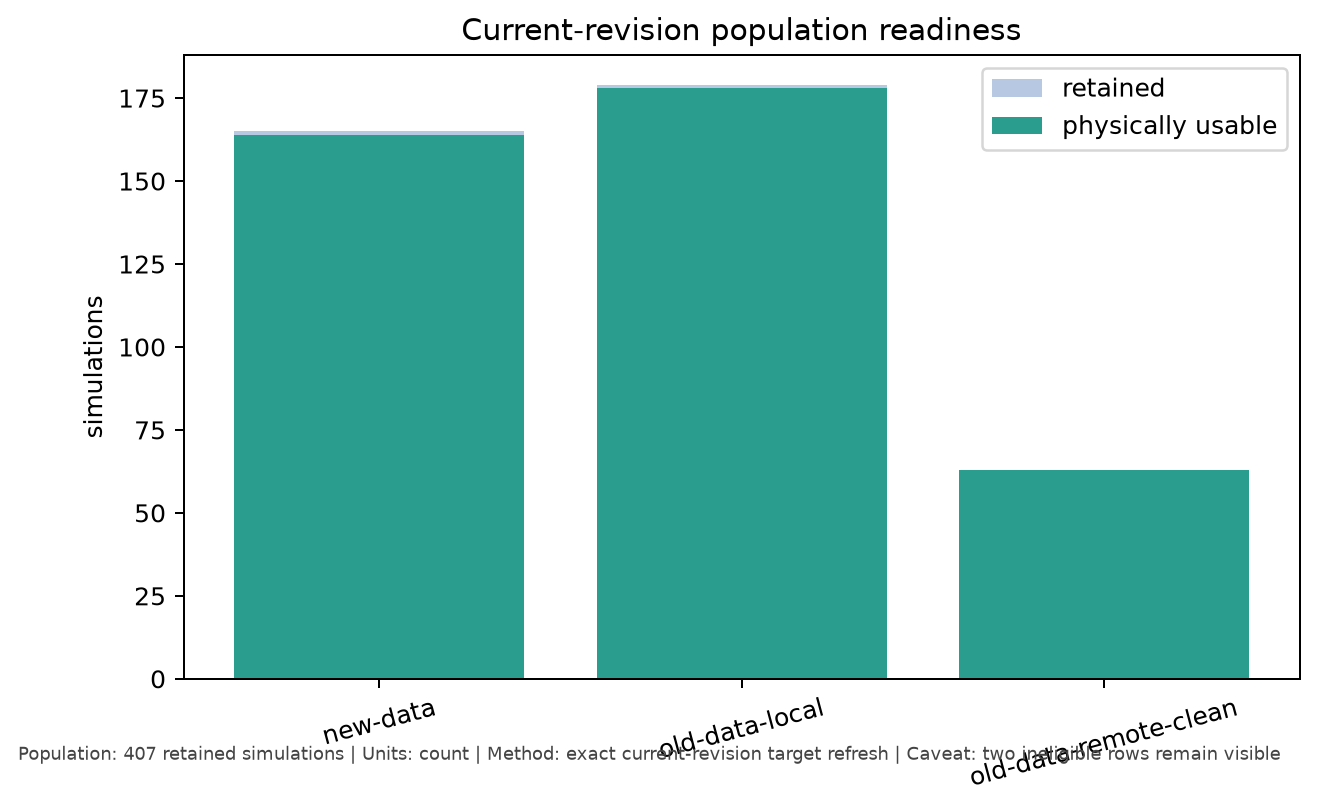

In [4]:
readiness = pd.read_csv(OUT / 'population_readiness_by_partition.csv')
display(readiness)
display(Image(filename=str(OUT / 'figures' / '01_partition_overview.png')))

**Result and interpretation.** Usable counts are 164/165 new, 178/179 old-local, 63/63 old-remote, and 405/407 overall. All 407 rows remain present.

## 5. Partition label composition

**What are we checking?** Compare manual Keyhole prevalence across partitions.

**Why does it matter?** Large prevalence shifts affect precision-recall results and threshold stability.

**Interpretation to avoid.** Do not interpret sparse old-data positives as proof that the physical process changed.

,population,experiment_count,keyhole_positive_count,keyhole_negative_count,keyhole_positive_fraction,conduction_positive_count,target_ready_keyhole_positive_count,target_ready_keyhole_negative_count
0,new-data,165,63,102,0.381818,133,63,101
1,old-data-local,179,8,171,0.044693,178,8,170
2,old-data-remote-clean,63,2,61,0.031746,62,2,61
3,all-old,242,10,232,0.041322,240,10,231
4,all-combined,407,73,334,0.179361,373,73,332


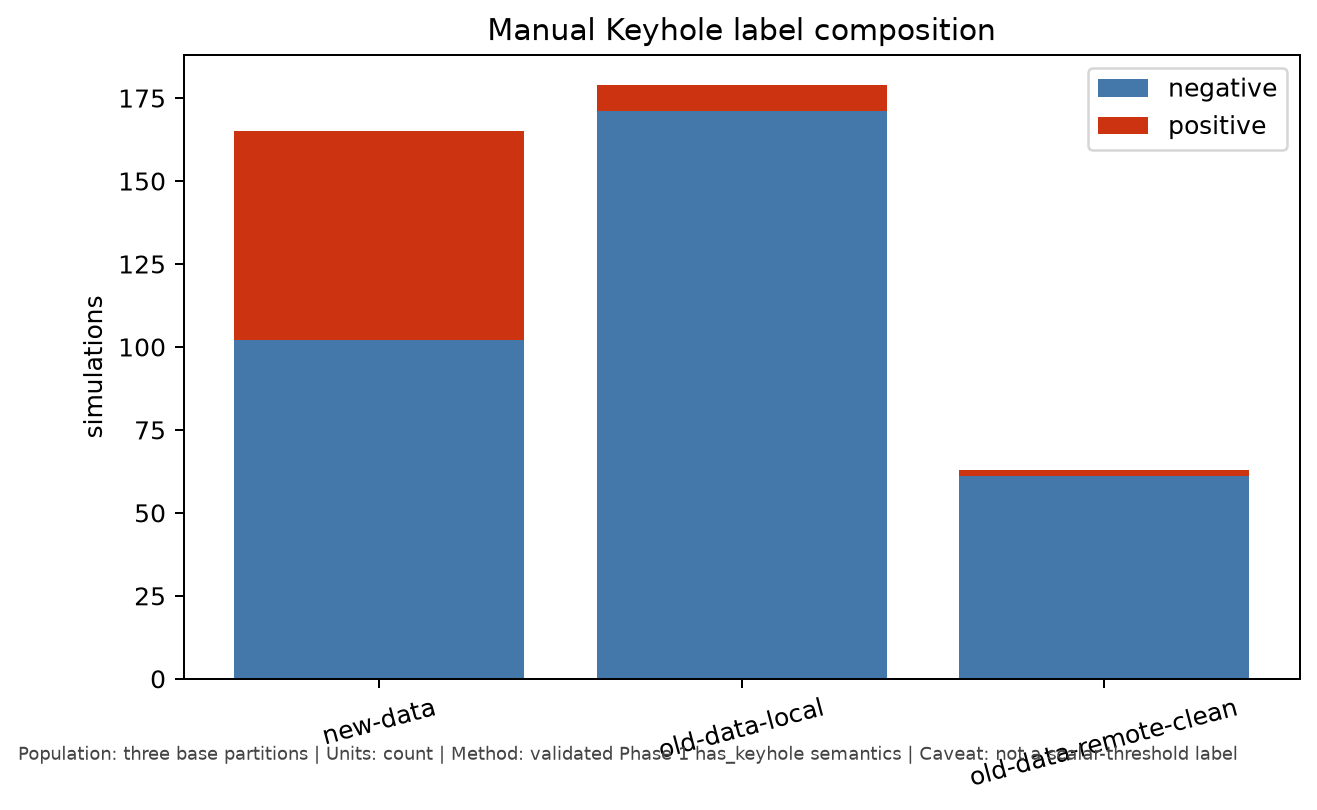

In [5]:
composition = pd.read_csv(OUT / 'label_composition_by_partition.csv')
display(composition)
display(Image(filename=str(OUT / 'figures' / '02_label_composition.png')))

**Result and interpretation.** Keyhole prevalence is 38.2% in new-data, 4.5% in old-local, and 3.2% in old-remote. The old partitions therefore provide a severe sparse-positive stress test.

## 6. Reminder: what G3, R3, max depth, and T0 depth mean

**What are we checking?** Restate the four primary scalar definitions before comparing metrics.

**Why does it matter?** The candidates answer different physical questions: persistence, ratio, spike, and late-window depth.

**Interpretation to avoid.** A higher AUC does not make two physical definitions interchangeable.

In [6]:
definitions = pd.read_csv(ROOT / 'outputs' / 'week7_05_keyhole_physical_proxy_analysis' / 'physical_proxy_candidate_definitions.csv')
display(definitions[definitions['candidate_id'].isin(['G3','R3','max_depth','T0_depth'])][
    ['candidate_id','candidate_name','unit','definition','role']
])

,candidate_id,candidate_name,unit,definition,role
0,T0_depth,T0 penetration depth,um,Median penetration depth in the unchanged Phas...,primary late-active depth baseline
1,max_depth,Maximum penetration depth,um,Maximum valid penetration depth over the compl...,spike-sensitive depth diagnostic
2,G3,G3 persistent depth,um,Maximum trailing 50 um rolling-median depth in...,predefined persistent-depth candidate
3,R3,R3 persistent aspect ratio,dimensionless,Maximum trailing 50 um rolling-median depth/wi...,predefined persistent geometry candidate


**Result and interpretation.** G3 is the predefined 50 μm persistent-depth statistic; max depth is intentionally more spike-sensitive. Both remain comparisons to the manual morphology label, not label definitions.

## 7. Candidate distributions by partition and label

**What are we checking?** Inspect the raw scalar distributions before summarizing them with one score.

**Why does it matter?** Visible overlap, gaps, and partition shifts explain later threshold behavior.

**Interpretation to avoid.** Do not read boxplots as held-out validation.

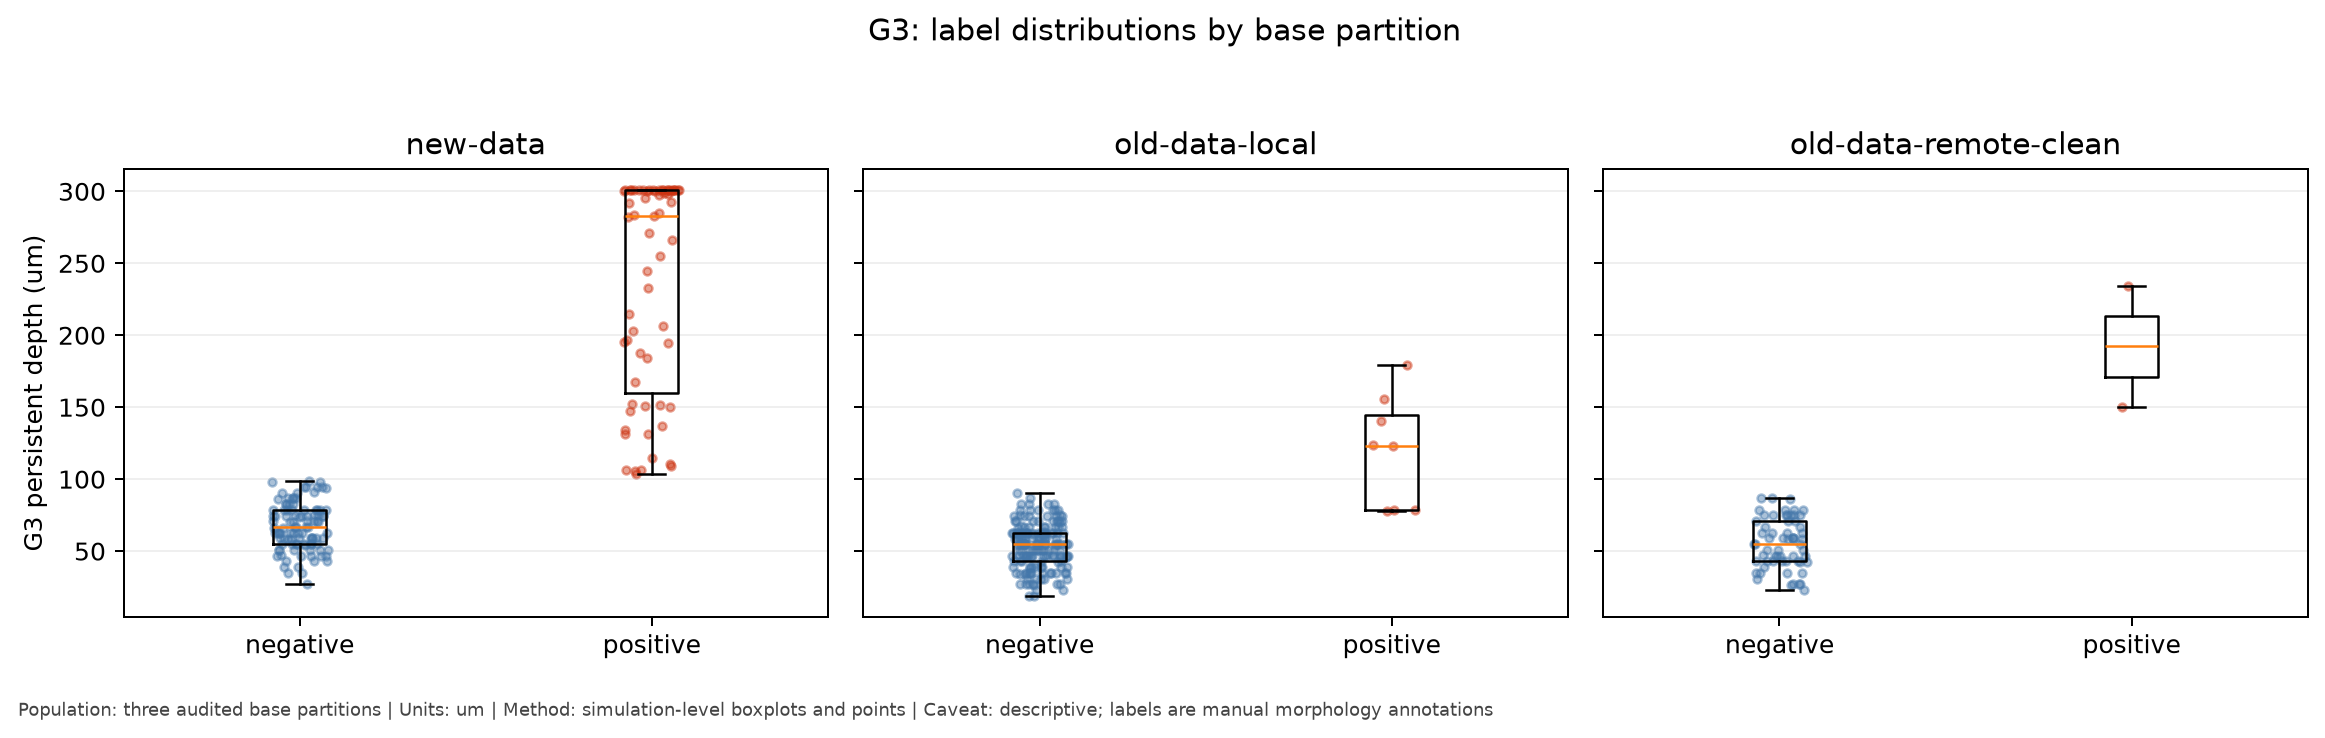

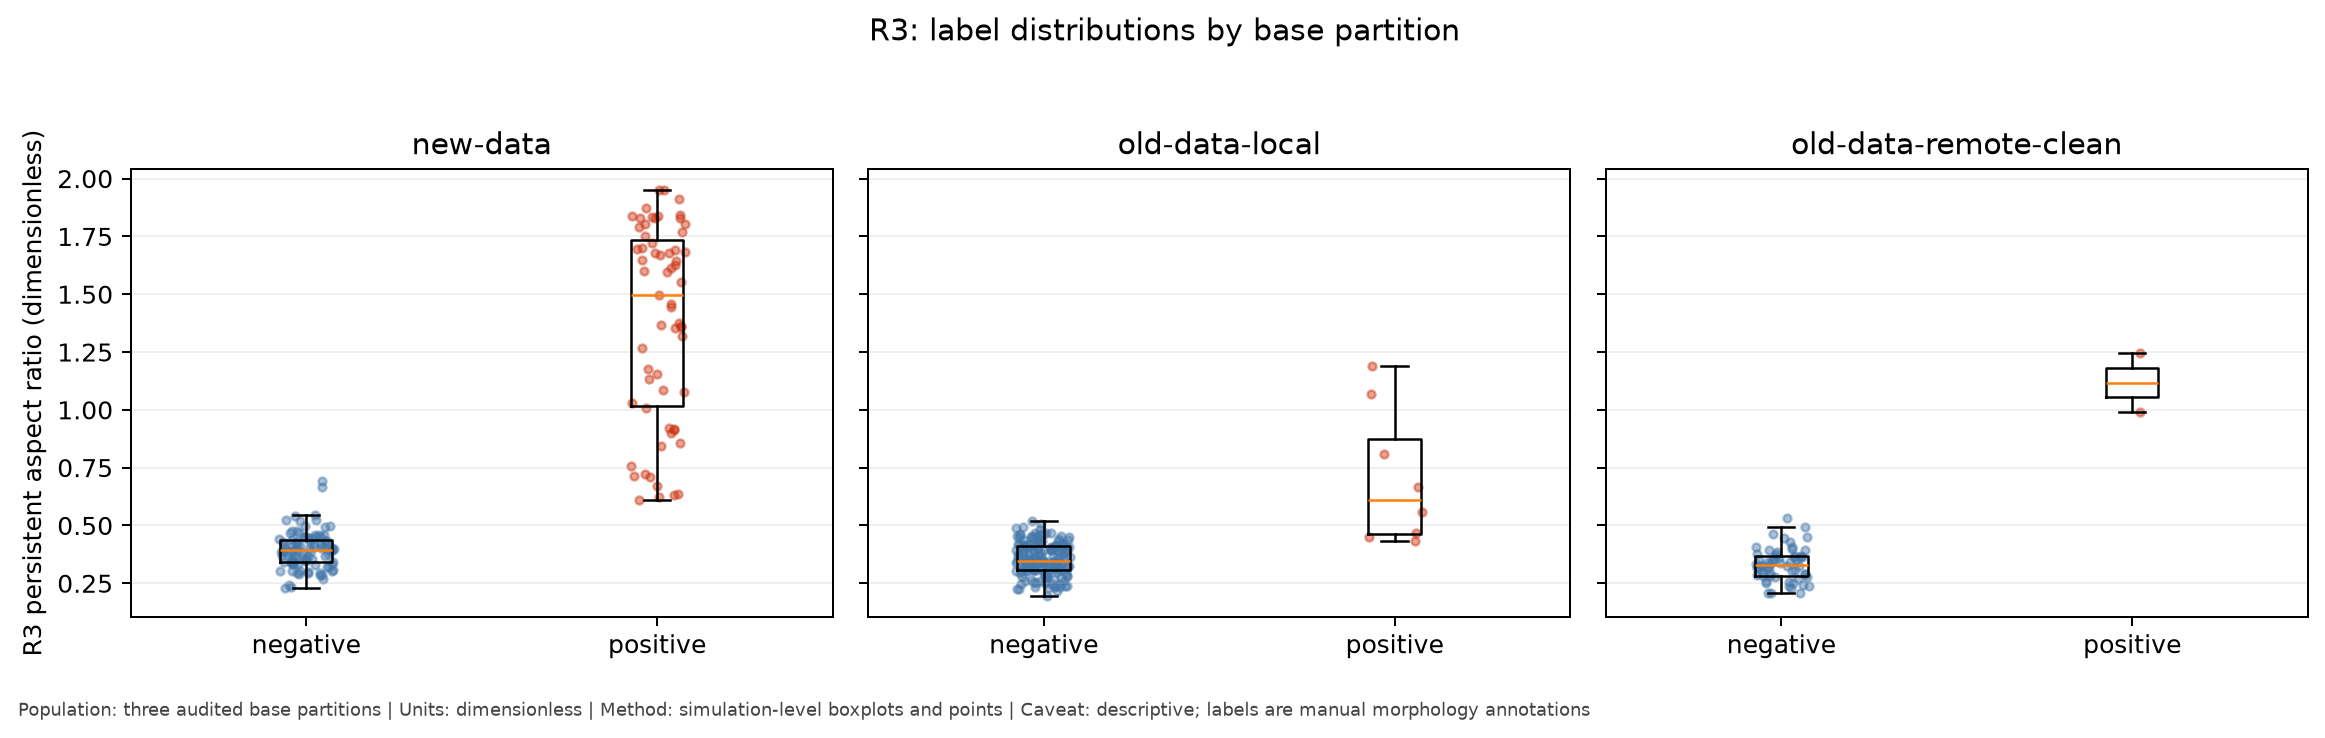

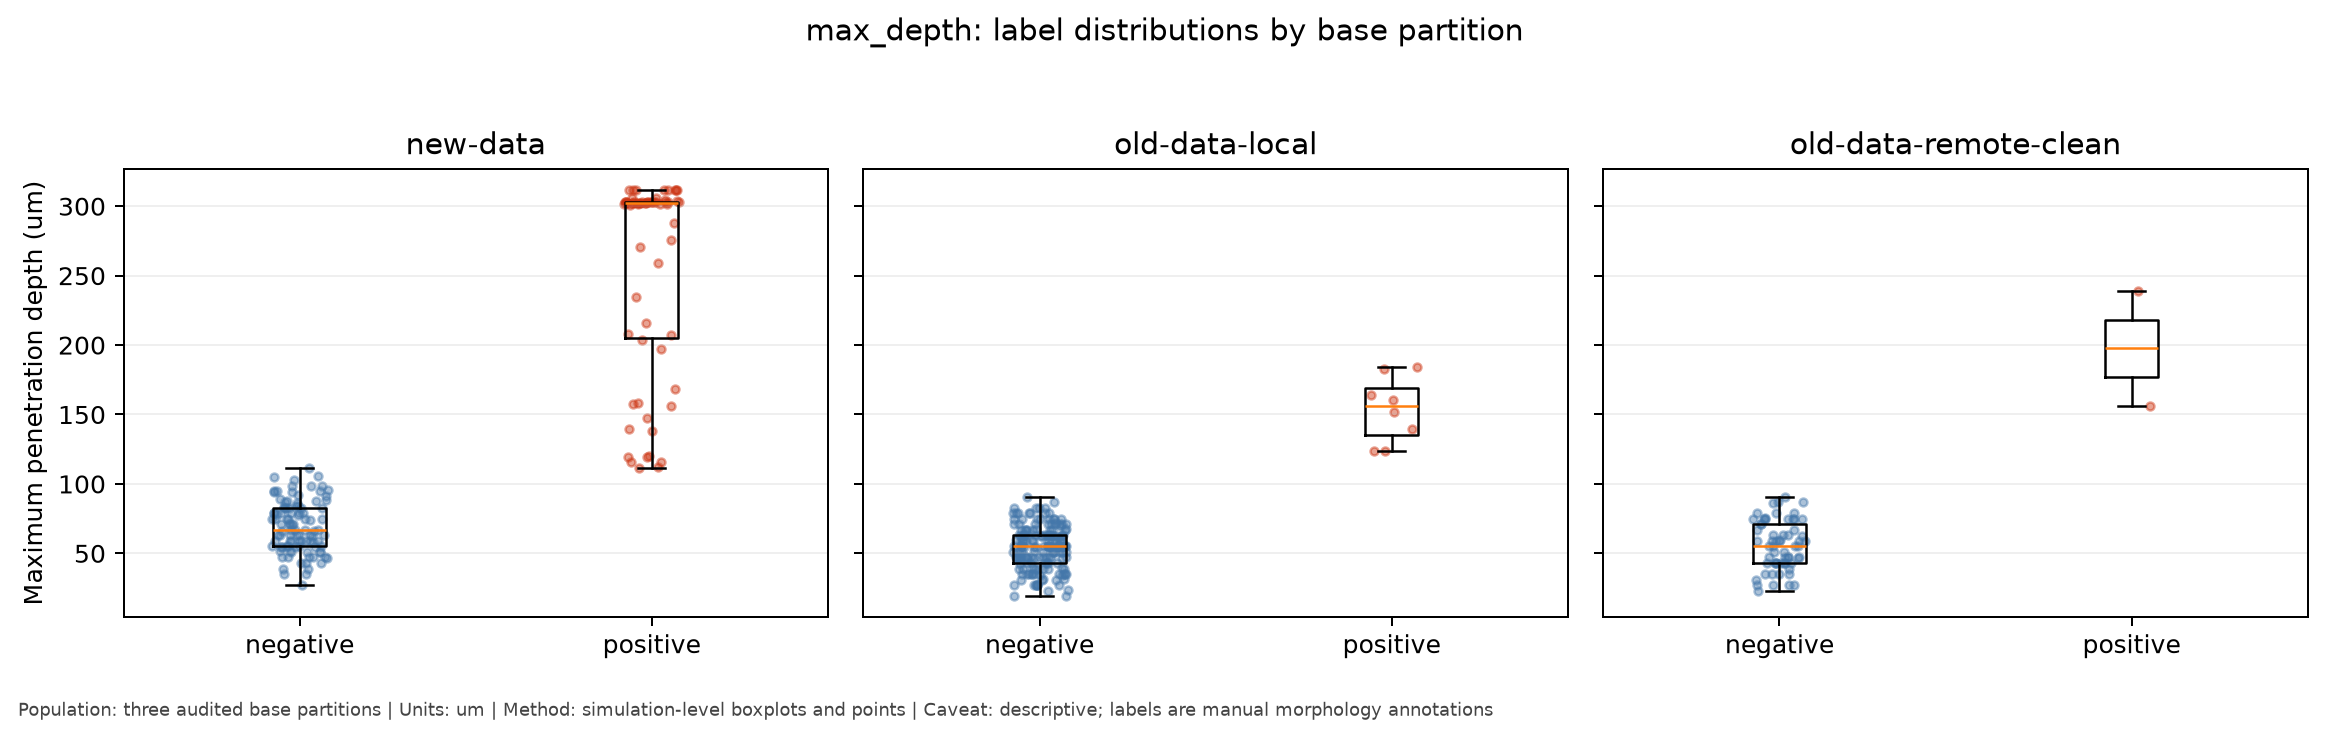

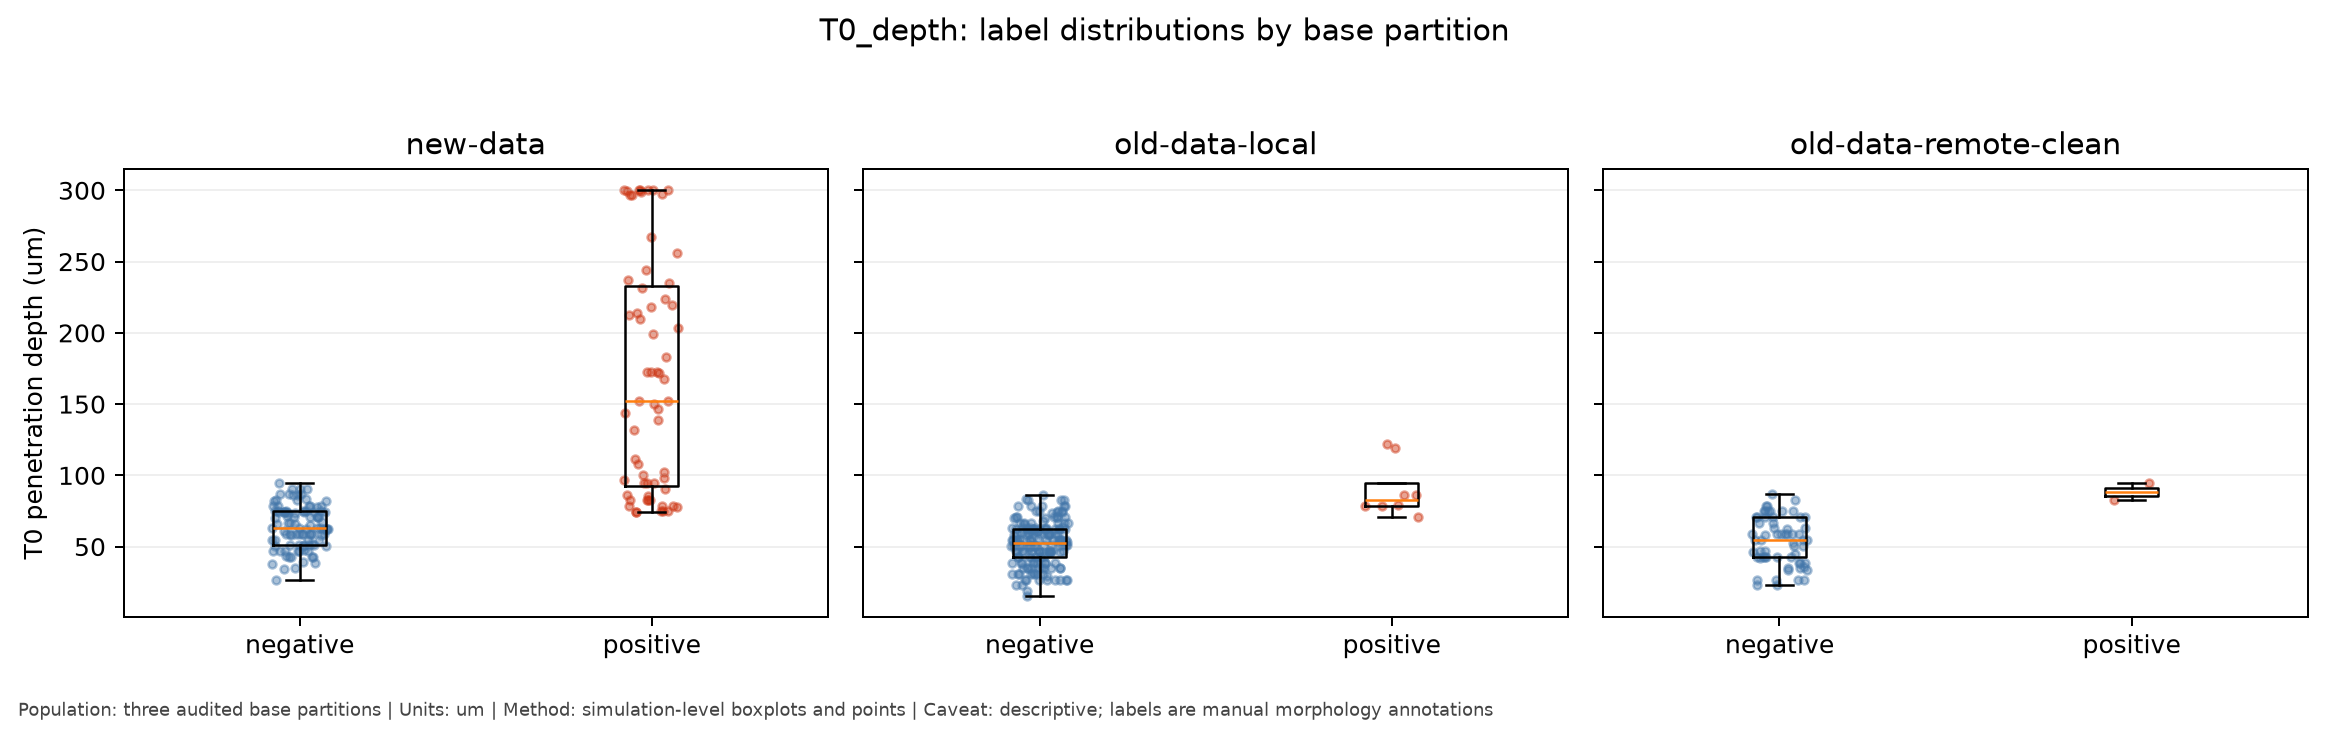

In [7]:
for name in ['03_G3_distributions.png','04_R3_distributions.png','05_max_depth_distributions.png','06_T0_depth_distributions.png']:
    display(Image(filename=str(OUT / 'figures' / name)))

**Result and interpretation.** G3 and max depth retain strong ordering, but old-local has visibly more negative/positive overlap and a lower G3 decision region than new-data.

## 8. Within-population LOO threshold performance

**What are we checking?** Select each threshold without the held-out simulation inside each population.

**Why does it matter?** This tests local threshold reproducibility while preventing single-row leakage.

**Interpretation to avoid.** Within-population LOO is not the same as transfer to another partition.

,population,candidate_id,cv_n,balanced_accuracy,sensitivity_keyhole_recall,specificity,false_positive,false_negative,full_data_descriptive_threshold
0,new-data,G3,164,1.000000,1.000000,1.000000,0,0,100.958763
1,new-data,R3,164,0.990099,1.000000,0.980198,2,0,0.578215
2,new-data,max_depth,164,0.987113,0.984127,0.990099,1,1,108.601000
5,new-data,T0_depth,164,0.778956,0.746032,0.811881,19,16,82.415067
8,old-data-local,max_depth,178,1.000000,1.000000,1.000000,0,0,107.081280
9,old-data-local,G3,177,0.964497,1.000000,0.928994,12,0,76.412915
10,old-data-local,T0_depth,178,0.869853,0.875000,0.864706,23,1,70.172368
11,old-data-local,R3,177,0.854660,0.875000,0.834320,28,1,0.431491
16,old-data-remote-clean,R3,63,1.000000,1.000000,1.000000,0,0,0.762495
17,old-data-remote-clean,max_depth,63,0.750000,0.500000,1.000000,0,1,123.209585


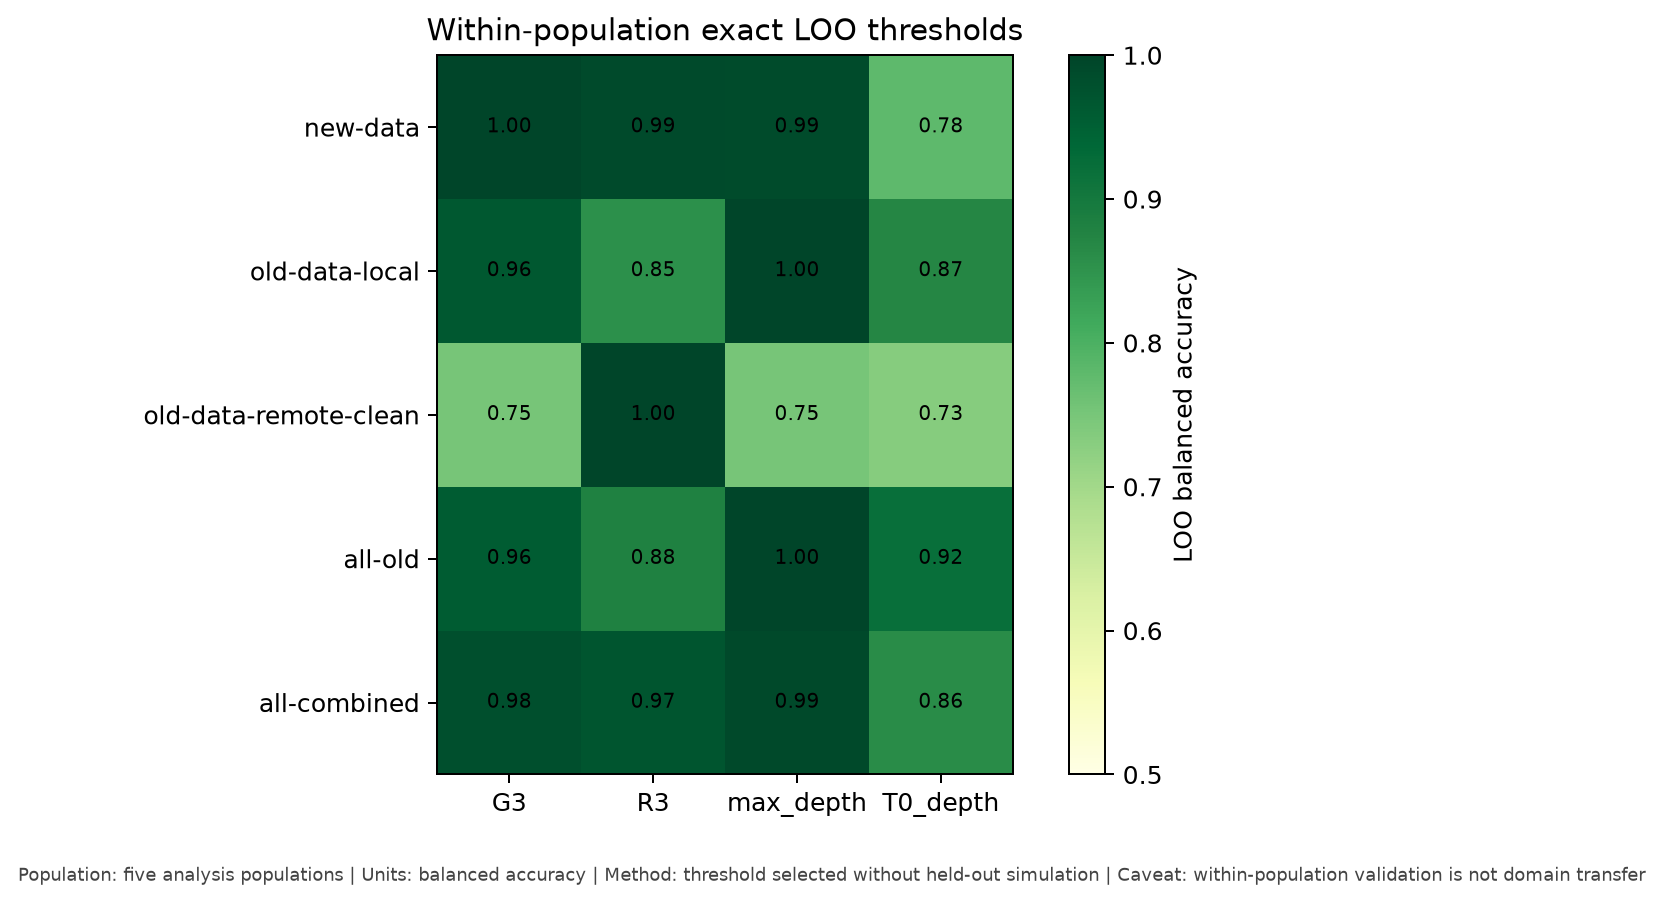

In [8]:
within = pd.read_csv(OUT / 'threshold_within_population_summary.csv')
display(within[within['candidate_id'].isin(['G3','R3','max_depth','T0_depth'])][
    ['population','candidate_id','cv_n','balanced_accuracy','sensitivity_keyhole_recall','specificity',
     'false_positive','false_negative','full_data_descriptive_threshold']
])
display(Image(filename=str(OUT / 'figures' / '11_within_population_performance.png')))

**Result and interpretation.** G3 LOO balanced accuracy is 1.000 in new-data, 0.964 in old-local, and 0.750 in old-remote. The last value is driven by only two positives and must be read with its interval.

## 9. Cross-population threshold transfer

**What are we checking?** Freeze a threshold on one population and evaluate it on a disjoint population.

**Why does it matter?** This is the direct test of whether the Phase 5 new-data threshold travels to old data and back.

**Interpretation to avoid.** Do not tune a threshold after looking at the test partition.

,route_id,candidate_id,train_n,test_n,training_selected_threshold,balanced_accuracy,sensitivity,specificity,false_positive,false_negative
0,new_to_old_local,T0_depth,164,178,82.415067,0.735294,0.500000,0.970588,5,4
1,new_to_old_local,max_depth,164,178,108.601000,1.000000,1.000000,1.000000,0,0
2,new_to_old_local,G3,164,177,100.958763,0.812500,0.625000,1.000000,0,3
3,new_to_old_local,R3,164,177,0.578215,0.750000,0.500000,1.000000,0,4
8,new_to_old_remote,T0_depth,164,63,82.415067,0.983607,1.000000,0.967213,2,0
9,new_to_old_remote,max_depth,164,63,108.601000,1.000000,1.000000,1.000000,0,0
10,new_to_old_remote,G3,164,63,100.958763,1.000000,1.000000,1.000000,0,0
11,new_to_old_remote,R3,164,63,0.578215,1.000000,1.000000,1.000000,0,0
16,new_to_all_old,T0_depth,164,241,82.415067,0.784848,0.600000,0.969697,7,4
17,new_to_all_old,max_depth,164,241,108.601000,1.000000,1.000000,1.000000,0,0


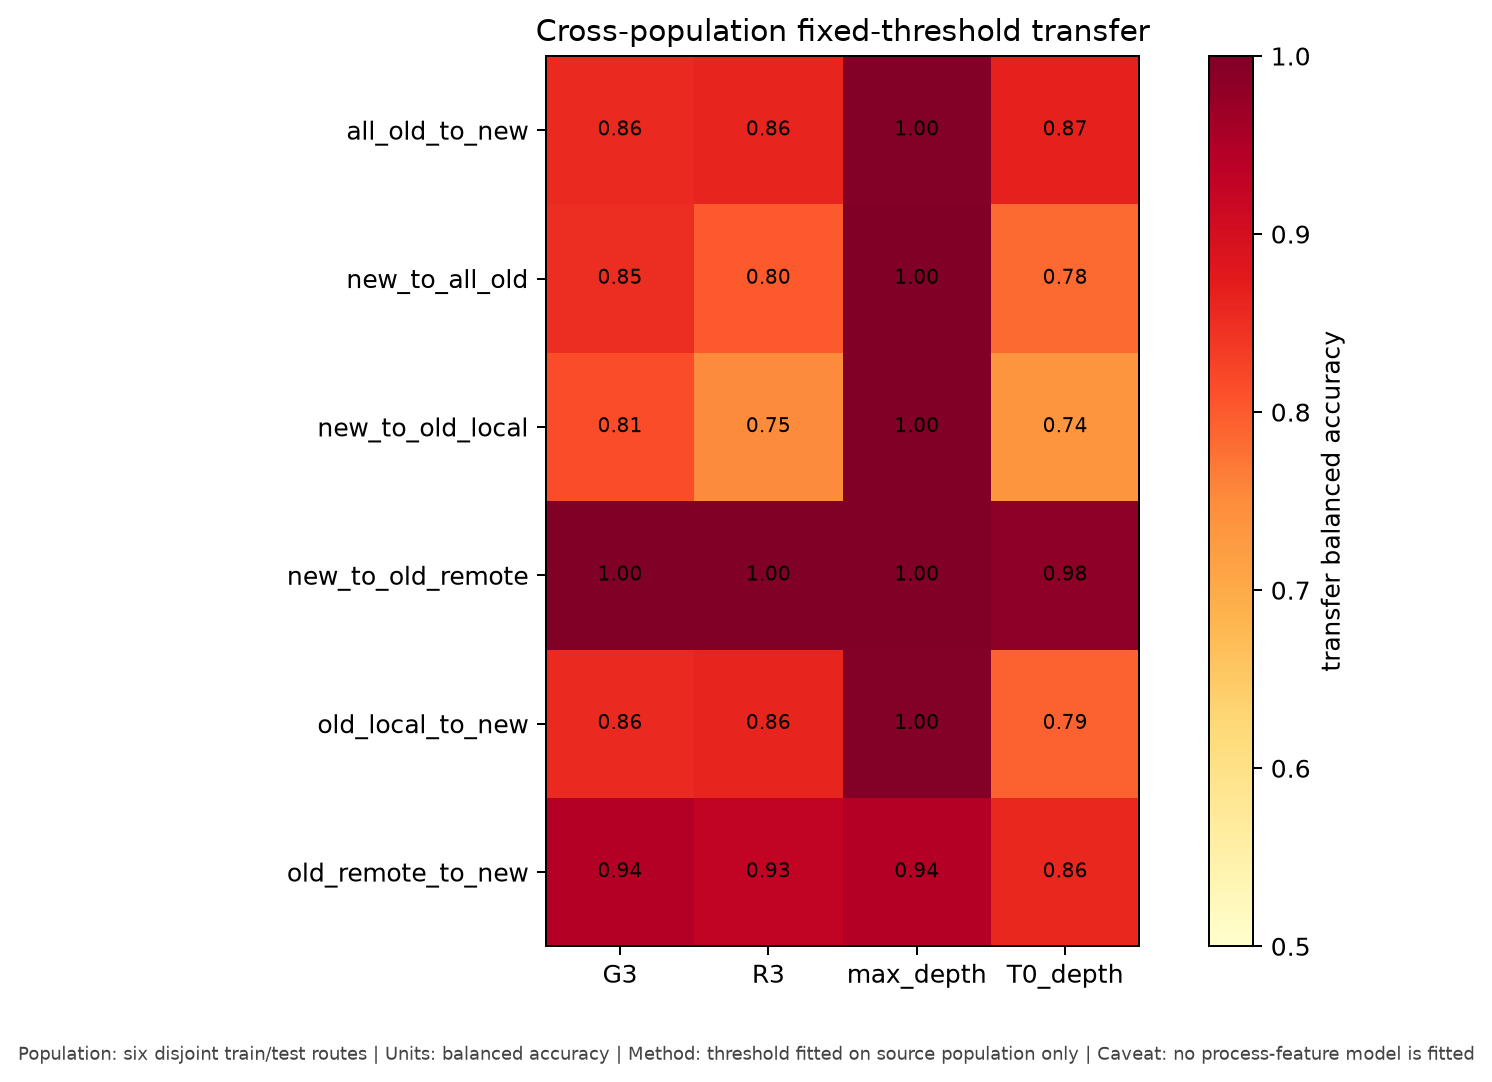

In [9]:
transfer = pd.read_csv(OUT / 'threshold_cross_population_transfer_summary.csv')
display(transfer[(transfer['candidate_id'].isin(['G3','R3','max_depth','T0_depth'])) &
                 (transfer['evaluation_type'] == 'cross_population_transfer')][
    ['route_id','candidate_id','train_n','test_n','training_selected_threshold','balanced_accuracy',
     'sensitivity','specificity','false_positive','false_negative']
])
display(Image(filename=str(OUT / 'figures' / '12_cross_population_transfer.png')))

**Result and interpretation.** For G3, new→old-local balanced accuracy is 0.812 with sensitivity 0.625; all-old→new is 0.856. G3 transfers directionally, but a single fixed threshold is not invariant.

## 10. Threshold stability

**What are we checking?** Compare fold-selected threshold distributions within each population.

**Why does it matter?** Stable direction can coexist with a shifted numerical threshold.

**Interpretation to avoid.** Do not call a threshold universal merely because its LOO IQR is small in one partition.

,population,candidate_id,majority_direction,majority_direction_fraction,threshold_median,threshold_iqr,threshold_iqr_over_candidate_iqr,stability_class
0,new-data,T0_depth,higher,1.0,82.415067,0.0,0.0,stable
1,new-data,max_depth,higher,1.0,108.601000,0.0,0.0,stable
2,new-data,G3,higher,1.0,100.958763,0.0,0.0,stable
3,new-data,R3,higher,1.0,0.578215,0.0,0.0,stable
8,old-data-local,T0_depth,higher,1.0,70.172368,0.0,0.0,stable
9,old-data-local,max_depth,higher,1.0,107.081280,0.0,0.0,stable
10,old-data-local,G3,higher,1.0,76.412915,0.0,0.0,stable
11,old-data-local,R3,higher,1.0,0.431491,0.0,0.0,stable
16,old-data-remote-clean,T0_depth,higher,1.0,80.683710,0.0,0.0,stable
17,old-data-remote-clean,max_depth,higher,1.0,123.209585,0.0,0.0,stable


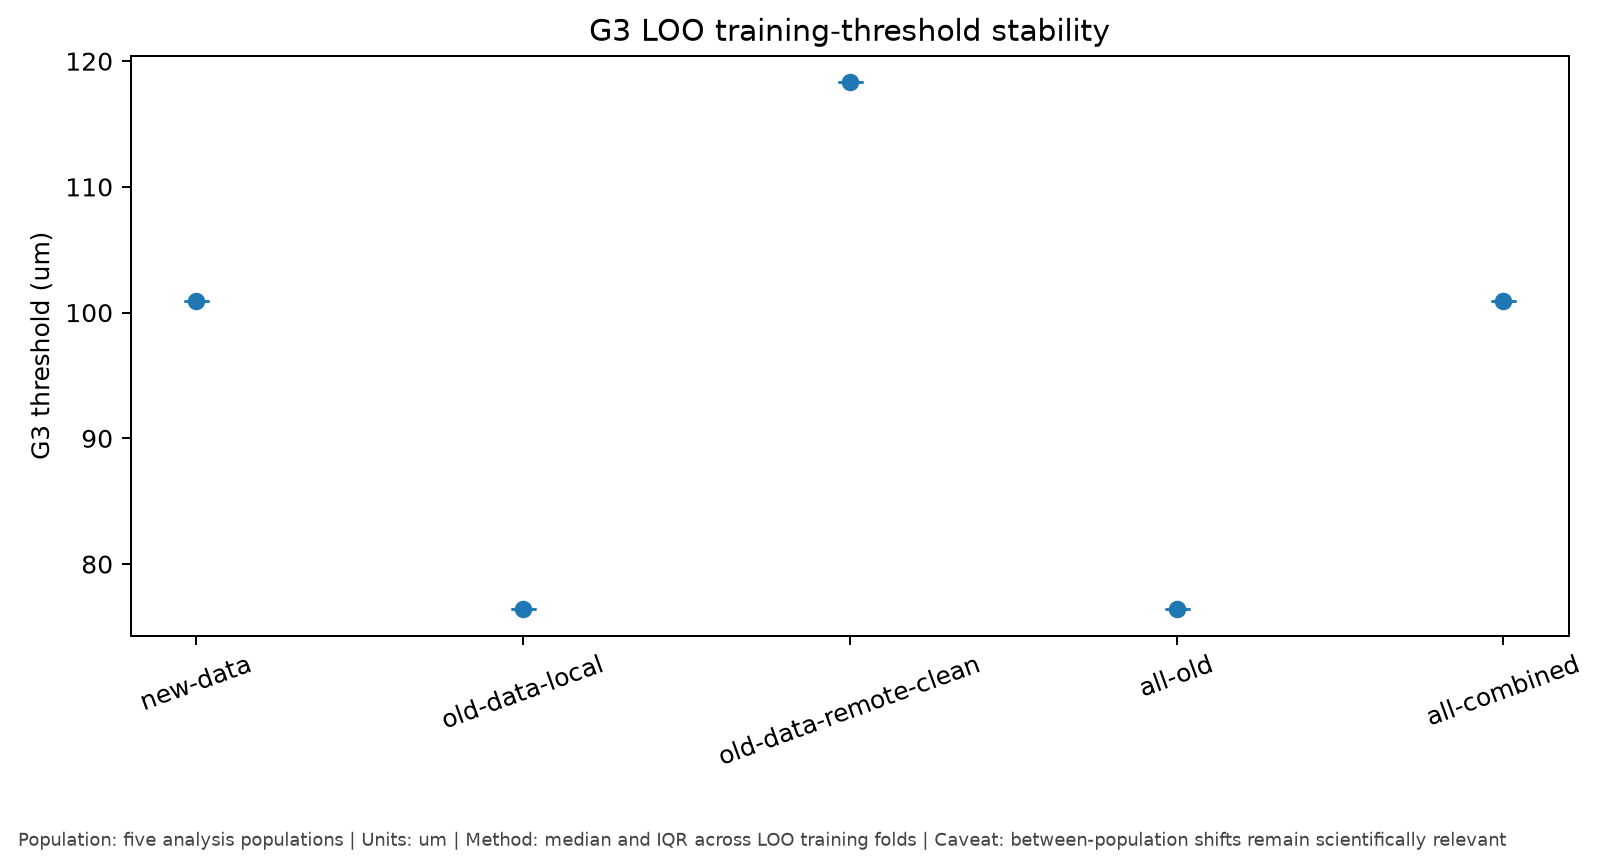

In [10]:
stability = pd.read_csv(OUT / 'threshold_stability_summary.csv')
display(stability[stability['candidate_id'].isin(['G3','R3','max_depth','T0_depth'])][
    ['population','candidate_id','majority_direction','majority_direction_fraction','threshold_median',
     'threshold_iqr','threshold_iqr_over_candidate_iqr','stability_class']
])
display(Image(filename=str(OUT / 'figures' / '13_threshold_stability.png')))

**Result and interpretation.** G3 points upward in every population, but descriptive thresholds shift from 76.4 μm (old-local) to 101.0 μm (new) and 118.3 μm (old-remote). Direction is robust; location is domain-sensitive.

## 11. Threshold margin and gap diagnostics

**What are we checking?** Measure the nearest cases and occupancy around each descriptive threshold.

**Why does it matter?** An empty gap is stronger descriptive evidence than a threshold sitting inside dense overlap.

**Interpretation to avoid.** A sample gap is not guaranteed to persist in future simulations.

,population,descriptive_threshold,class_gap_in_positive_direction,empty_class_gap,threshold_inside_empty_gap,within_band_count,nearest_below_distance,nearest_above_distance
0,new-data,100.958763,4.786075,True,True,0,2.393038,2.393037
12,old-data-local,76.412915,-12.198360,False,False,8,1.596725,1.596725
24,old-data-remote-clean,118.326565,63.046970,True,True,0,31.523485,31.523485
36,all-old,76.435635,-12.198360,False,False,15,1.574005,1.574005
48,all-combined,100.958763,-20.556085,False,False,0,2.393038,2.393037


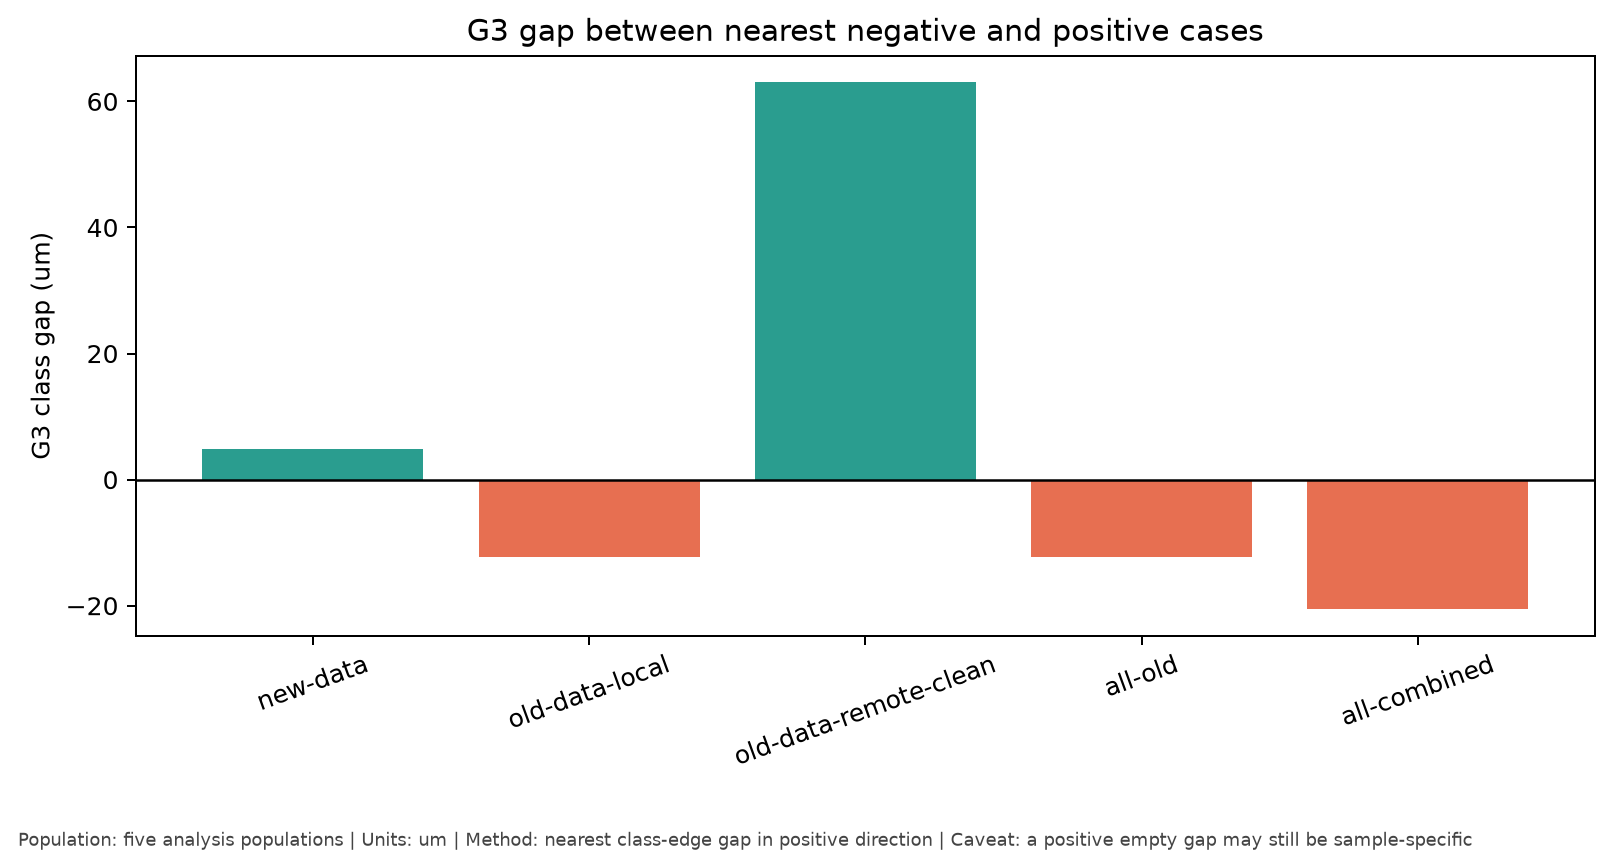

In [11]:
margins = pd.read_csv(OUT / 'threshold_margin_diagnostics.csv')
display(margins[(margins['candidate_id'] == 'G3') & (margins['band_half_width'] == 2.0)][
    ['population','descriptive_threshold','class_gap_in_positive_direction','empty_class_gap',
     'threshold_inside_empty_gap','within_band_count','nearest_below_distance','nearest_above_distance']
])
display(Image(filename=str(OUT / 'figures' / '08_threshold_gap_margin.png')))

**Result and interpretation.** New-data has a 4.79 μm empty G3 gap, while old-local has overlap (-12.20 μm signed gap). The perfect Phase 5 separation is therefore not reproduced as a universal class gap.

## 12. Bootstrap uncertainty

**What are we checking?** Attach simulation-level 95% intervals to rank, LOO, and transfer metrics.

**Why does it matter?** Sparse positive classes can make a seemingly good point estimate imprecise.

**Interpretation to avoid.** Do not treat 5,000 resamples as 5,000 independent simulations.

,analysis_type,population_or_route,metric,estimate,ci_low,ci_high,bootstrap_resamples,bootstrap_unit
0,within_population,new-data,roc_auc,1.000000,1.000000,1.000000,5000,simulation
1,within_population,new-data,average_precision,1.000000,1.000000,1.000000,5000,simulation
2,within_population,new-data,loo_balanced_accuracy,1.000000,1.000000,1.000000,5000,simulation
20,within_population,old-data-local,roc_auc,0.973373,0.940828,0.995562,5000,simulation
21,within_population,old-data-local,average_precision,0.762719,0.524977,0.946429,5000,simulation
22,within_population,old-data-local,loo_balanced_accuracy,0.964497,0.943787,0.982249,5000,simulation
40,within_population,old-data-remote-clean,roc_auc,1.000000,1.000000,1.000000,5000,simulation
41,within_population,old-data-remote-clean,average_precision,1.000000,1.000000,1.000000,5000,simulation
42,within_population,old-data-remote-clean,loo_balanced_accuracy,0.750000,0.500000,1.000000,5000,simulation
60,within_population,all-old,roc_auc,0.975217,0.945217,1.000000,5000,simulation


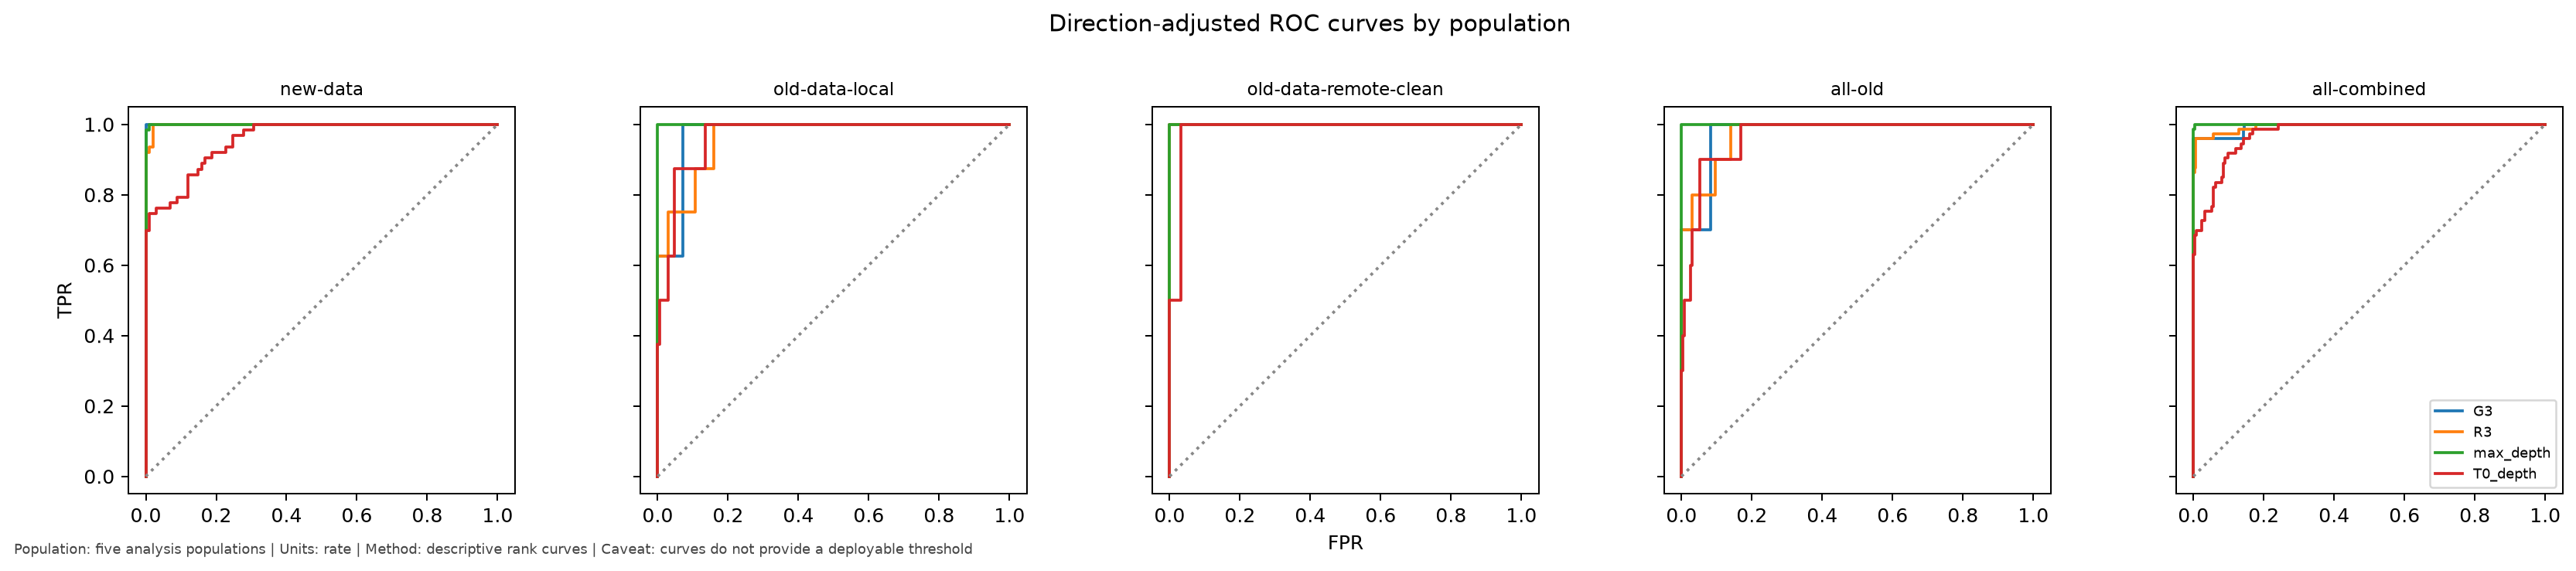

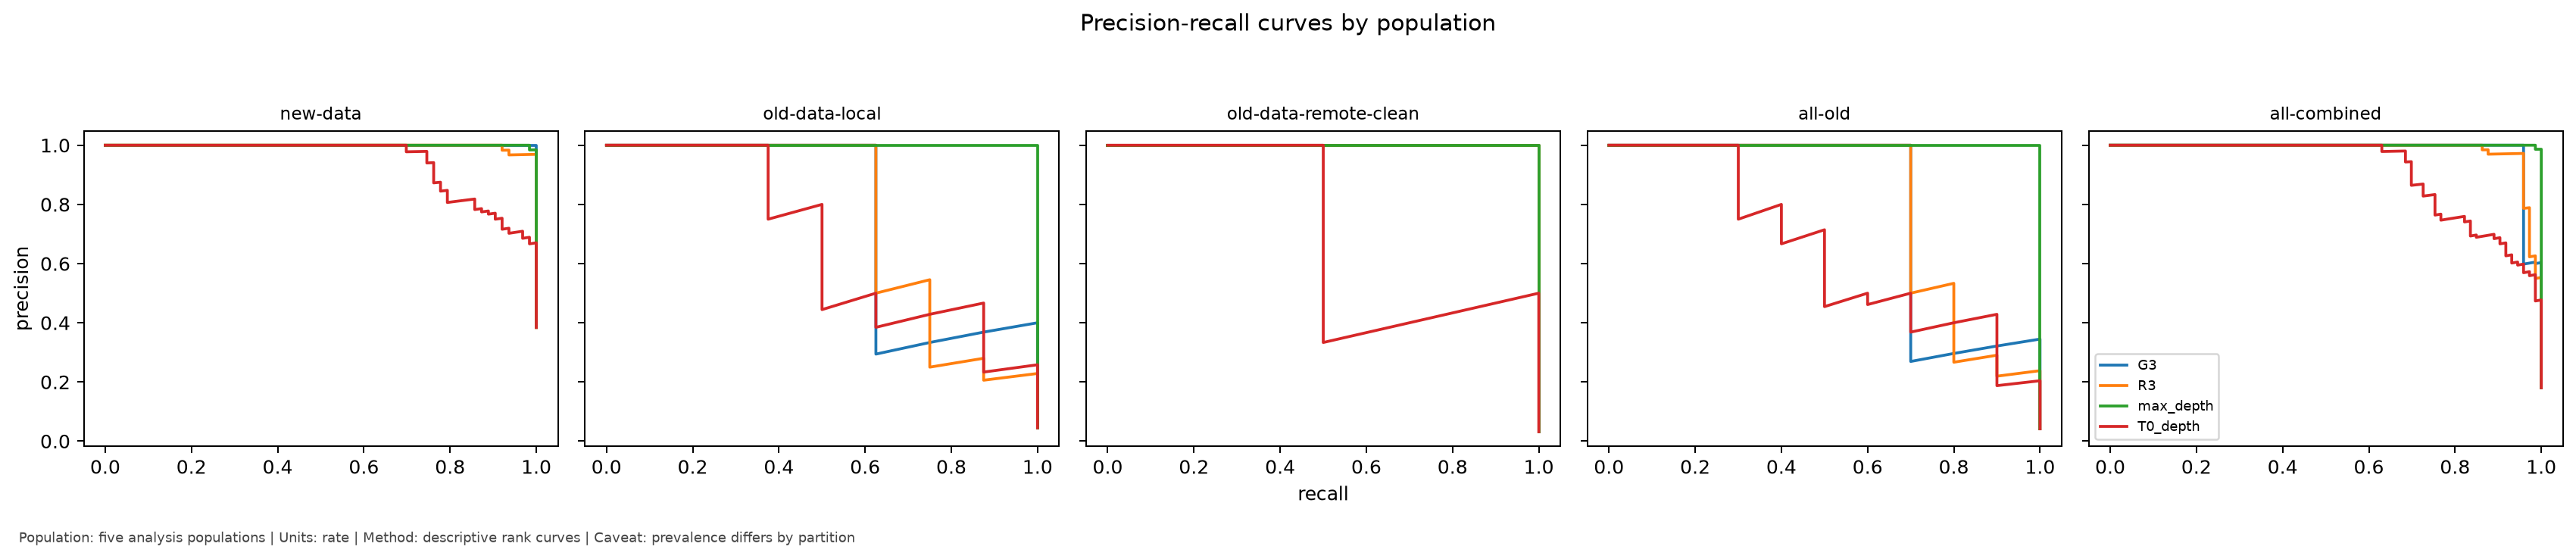

In [12]:
boot = pd.read_csv(OUT / 'proxy_bootstrap_uncertainty_summary.csv')
display(boot[(boot['candidate_id'] == 'G3') &
             (boot['metric'].isin(['roc_auc','average_precision','loo_balanced_accuracy','transfer_balanced_accuracy']))][
    ['analysis_type','population_or_route','metric','estimate','ci_low','ci_high','bootstrap_resamples','bootstrap_unit']
])
display(Image(filename=str(OUT / 'figures' / '09_roc_by_population.png')))
display(Image(filename=str(OUT / 'figures' / '10_pr_by_population.png')))

**Result and interpretation.** Old-remote G3 LOO balanced accuracy is 0.75, but its 95% interval is 0.50–1.00. The interval correctly exposes the two-positive limitation.

## 13. Transient vs persistent robustness

**What are we checking?** Compare G3 and the other main candidates across label-sequence persistence groups.

**Why does it matter?** A useful proxy should not work only for long persistent Keyhole episodes.

**Interpretation to avoid.** Saved-frame persistence is still an annotation subgroup, not continuous dwell time.

,population,subgroup_type,subgroup,candidate_id,n,keyhole_positive_n,mean,median,q25,q75,minimum,maximum
0,new-data,transient_persistent,Keyhole-negative,G3,101,0,66.925208,66.523210,54.825360,78.726440,27.061710,98.565725
1,new-data,transient_persistent,persistent Keyhole,G3,33,33,284.729861,300.572100,292.327700,300.872400,184.307850,301.241700
2,new-data,transient_persistent,transient Keyhole,G3,30,30,183.101163,151.767800,131.459087,242.813337,103.351800,301.205600
3,new-data,transient_persistent,Keyhole-negative,R3,101,0,0.393136,0.392888,0.341228,0.437631,0.228077,0.692225
4,new-data,transient_persistent,persistent Keyhole,R3,33,33,1.625331,1.680002,1.551246,1.828830,0.710744,1.952717
5,new-data,transient_persistent,transient Keyhole,R3,30,30,1.116388,1.017927,0.777958,1.372185,0.610100,1.839695
6,new-data,transient_persistent,Keyhole-negative,max_depth,101,0,69.283411,66.837000,55.066460,82.933150,27.372390,111.583800
7,new-data,transient_persistent,persistent Keyhole,max_depth,33,33,292.597512,302.677300,301.903300,302.946700,197.104200,311.995200
8,new-data,transient_persistent,transient Keyhole,max_depth,30,30,215.535933,205.709000,138.520675,302.776050,111.198200,311.999900
9,new-data,transient_persistent,Keyhole-negative,T0_depth,101,0,63.875443,62.753340,50.871395,74.646610,26.909320,94.620220


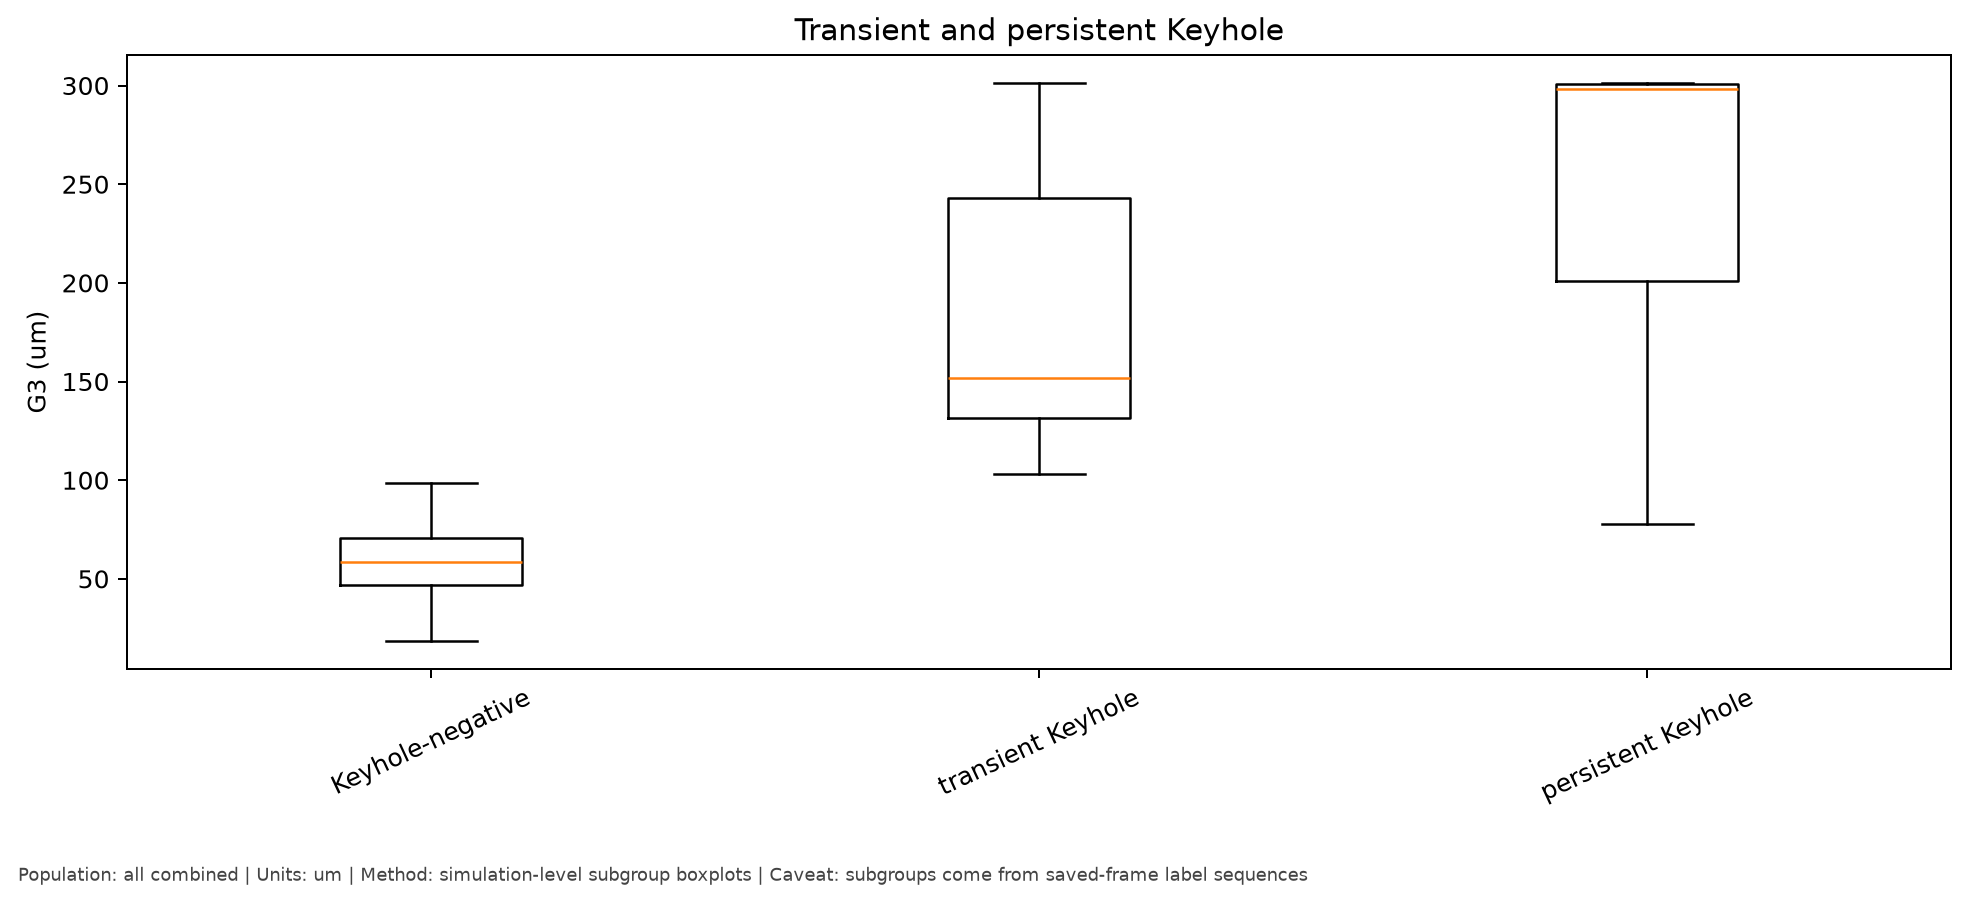

In [13]:
persistence = pd.read_csv(OUT / 'subgroup_transient_persistent_summary.csv')
display(persistence[(persistence['candidate_id'].isin(['G3','R3','max_depth','T0_depth'])) &
                    (persistence['subgroup_type'] == 'transient_persistent')])
display(Image(filename=str(OUT / 'figures' / '14_persistence_subgroups.png')))

**Result and interpretation.** G3 remains elevated for transient and persistent positive groups, but sparse old-data positives prevent a strong partition-specific persistence claim.

## 14. T0-overlap timing robustness

**What are we checking?** Stratify proxy values by where Keyhole-labelled frames fall relative to T0.

**Why does it matter?** This checks whether late-window timing explains why T0 depth underperforms persistent/extreme measures.

**Interpretation to avoid.** Do not infer event causality from saved-frame alignment alone.

,population,subgroup_type,subgroup,candidate_id,n,keyhole_positive_n,mean,median,q25,q75,minimum,maximum
0,new-data,T0_timing,before_T0,G3,22,22,149.706875,142.280025,111.558500,163.470837,103.351800,283.356300
1,new-data,T0_timing,no_Keyhole,G3,101,0,66.925208,66.523210,54.825360,78.726440,27.061710,98.565725
2,new-data,T0_timing,spans_multiple_T0_regions,G3,41,41,282.818757,300.319400,282.998000,300.883600,184.307850,301.241700
3,new-data,T0_timing,before_T0,R3,22,22,0.930862,0.905593,0.716007,1.070070,0.610100,1.457665
4,new-data,T0_timing,no_Keyhole,R3,101,0,0.393136,0.392888,0.341228,0.437631,0.228077,0.692225
5,new-data,T0_timing,spans_multiple_T0_regions,R3,41,41,1.625575,1.680639,1.551246,1.828576,0.710744,1.952717
6,new-data,T0_timing,before_T0,max_depth,22,22,189.498132,156.611100,119.334300,274.453175,111.198200,311.999900
7,new-data,T0_timing,no_Keyhole,max_depth,101,0,69.283411,66.837000,55.066460,82.933150,27.372390,111.583800
8,new-data,T0_timing,spans_multiple_T0_regions,max_depth,41,41,291.532610,302.676700,301.879900,302.946700,197.104200,311.995200
9,new-data,T0_timing,before_T0,T0_depth,22,22,85.208113,82.557460,78.016497,93.405690,74.306600,111.341000


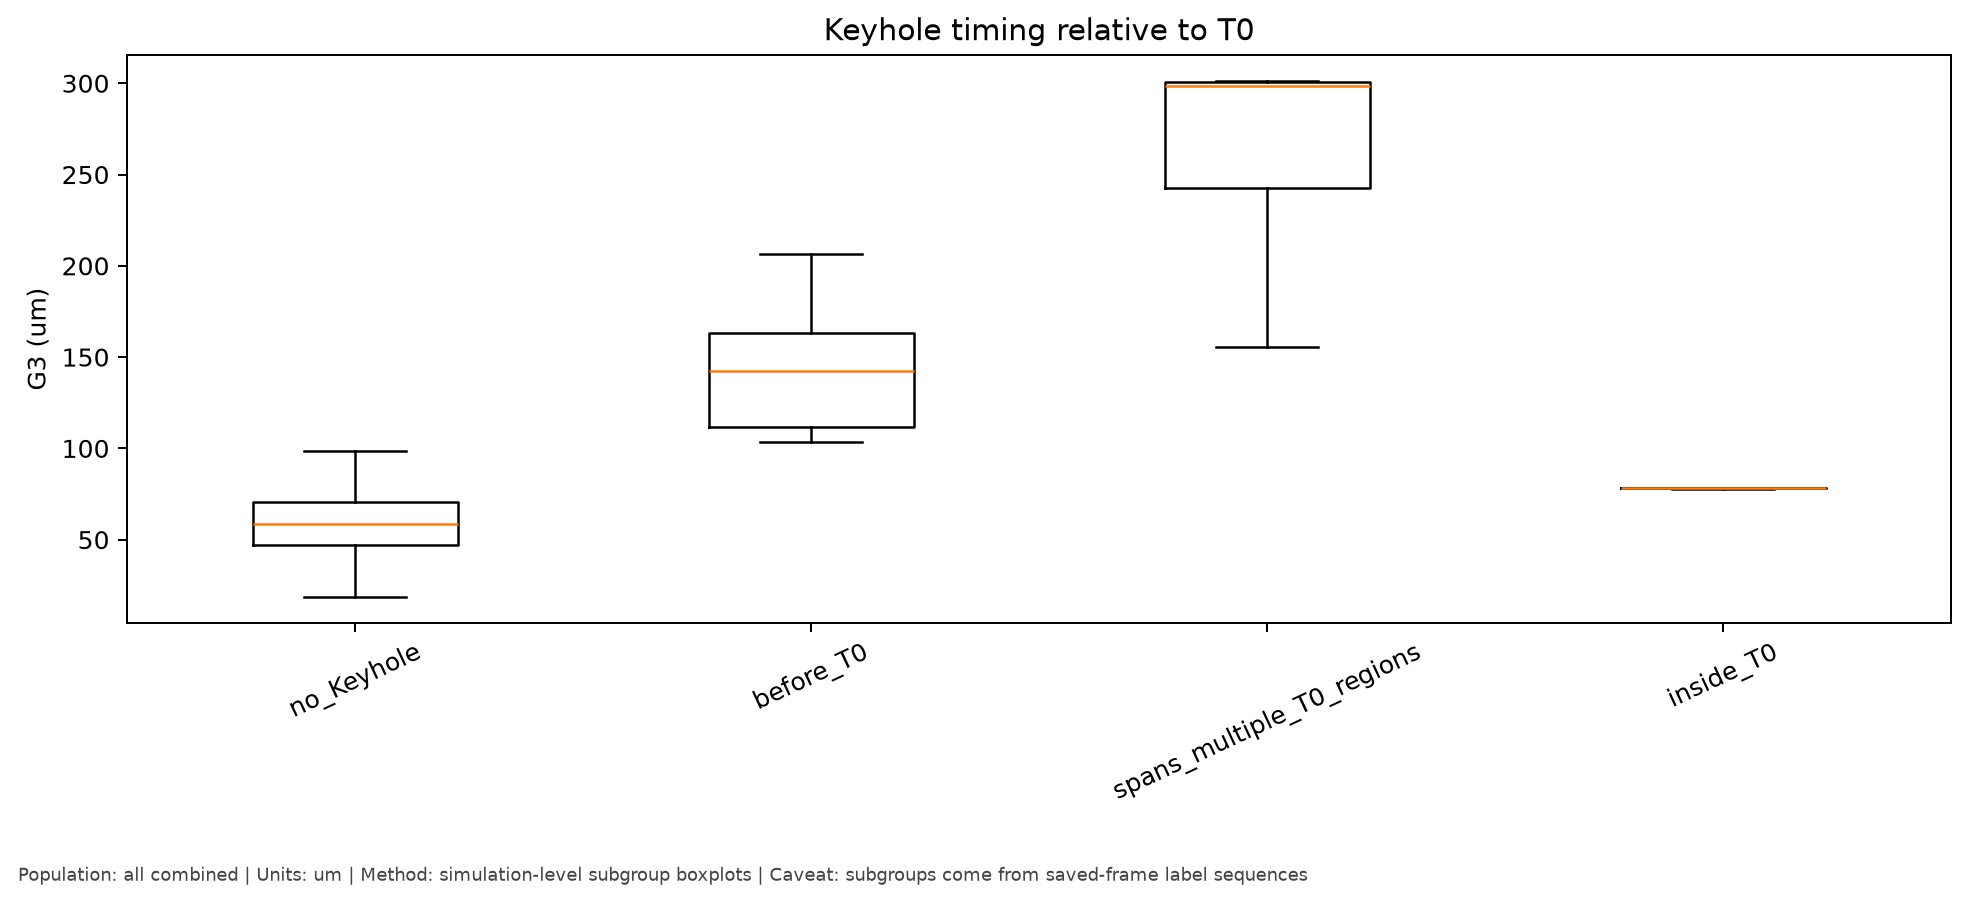

In [14]:
timing = pd.read_csv(OUT / 'subgroup_t0_timing_summary.csv')
display(timing[timing['candidate_id'].isin(['G3','R3','max_depth','T0_depth'])])
display(Image(filename=str(OUT / 'figures' / '15_t0_timing_subgroups.png')))

**Result and interpretation.** Persistent and extreme measures retain information when Keyhole occurs outside the late T0 window; this is consistent with T0 depth's weaker transfer score, without proving a causal timing mechanism.

## 15. Old vs new domain and process-map context

**What are we checking?** Compare P–VX coverage and G3 values across base partitions.

**Why does it matter?** Threshold movement may reflect domain composition as well as label prevalence.

**Interpretation to avoid.** These maps are descriptive and are not a fitted process boundary.

,population,experiment_count,P_min_W,P_median_W,P_max_W,VX_min_m_per_s,VX_median_m_per_s,VX_max_m_per_s,LS_min_um,LS_max_um,ST_min_K,ST_max_K,keyhole_positive_fraction,G3_available_n,G3_median_um,G3_iqr_um
0,new-data,165,102.928147,265.432978,449.762376,0.203591,0.639693,0.993777,40.029347,88.765220,300.218383,399.817711,0.381818,164,82.545080,135.227719
1,old-data-local,179,52.544586,151.505872,248.695097,0.201002,0.635787,0.995510,45.000000,88.456880,300.000000,399.182507,0.044693,177,54.901590,20.674740
2,old-data-remote-clean,63,76.698613,162.201107,246.882256,0.225166,0.584147,0.998321,45.309138,89.703986,306.057191,399.457924,0.031746,63,58.623580,29.916052
3,all-old,242,52.544586,154.405438,248.695097,0.201002,0.619103,0.998321,45.000000,89.703986,300.000000,399.457924,0.041322,240,54.907320,23.832277
4,all-combined,407,52.544586,193.813974,449.762376,0.201002,0.633805,0.998321,40.029347,89.703986,300.000000,399.817711,0.179361,404,62.790595,31.795374


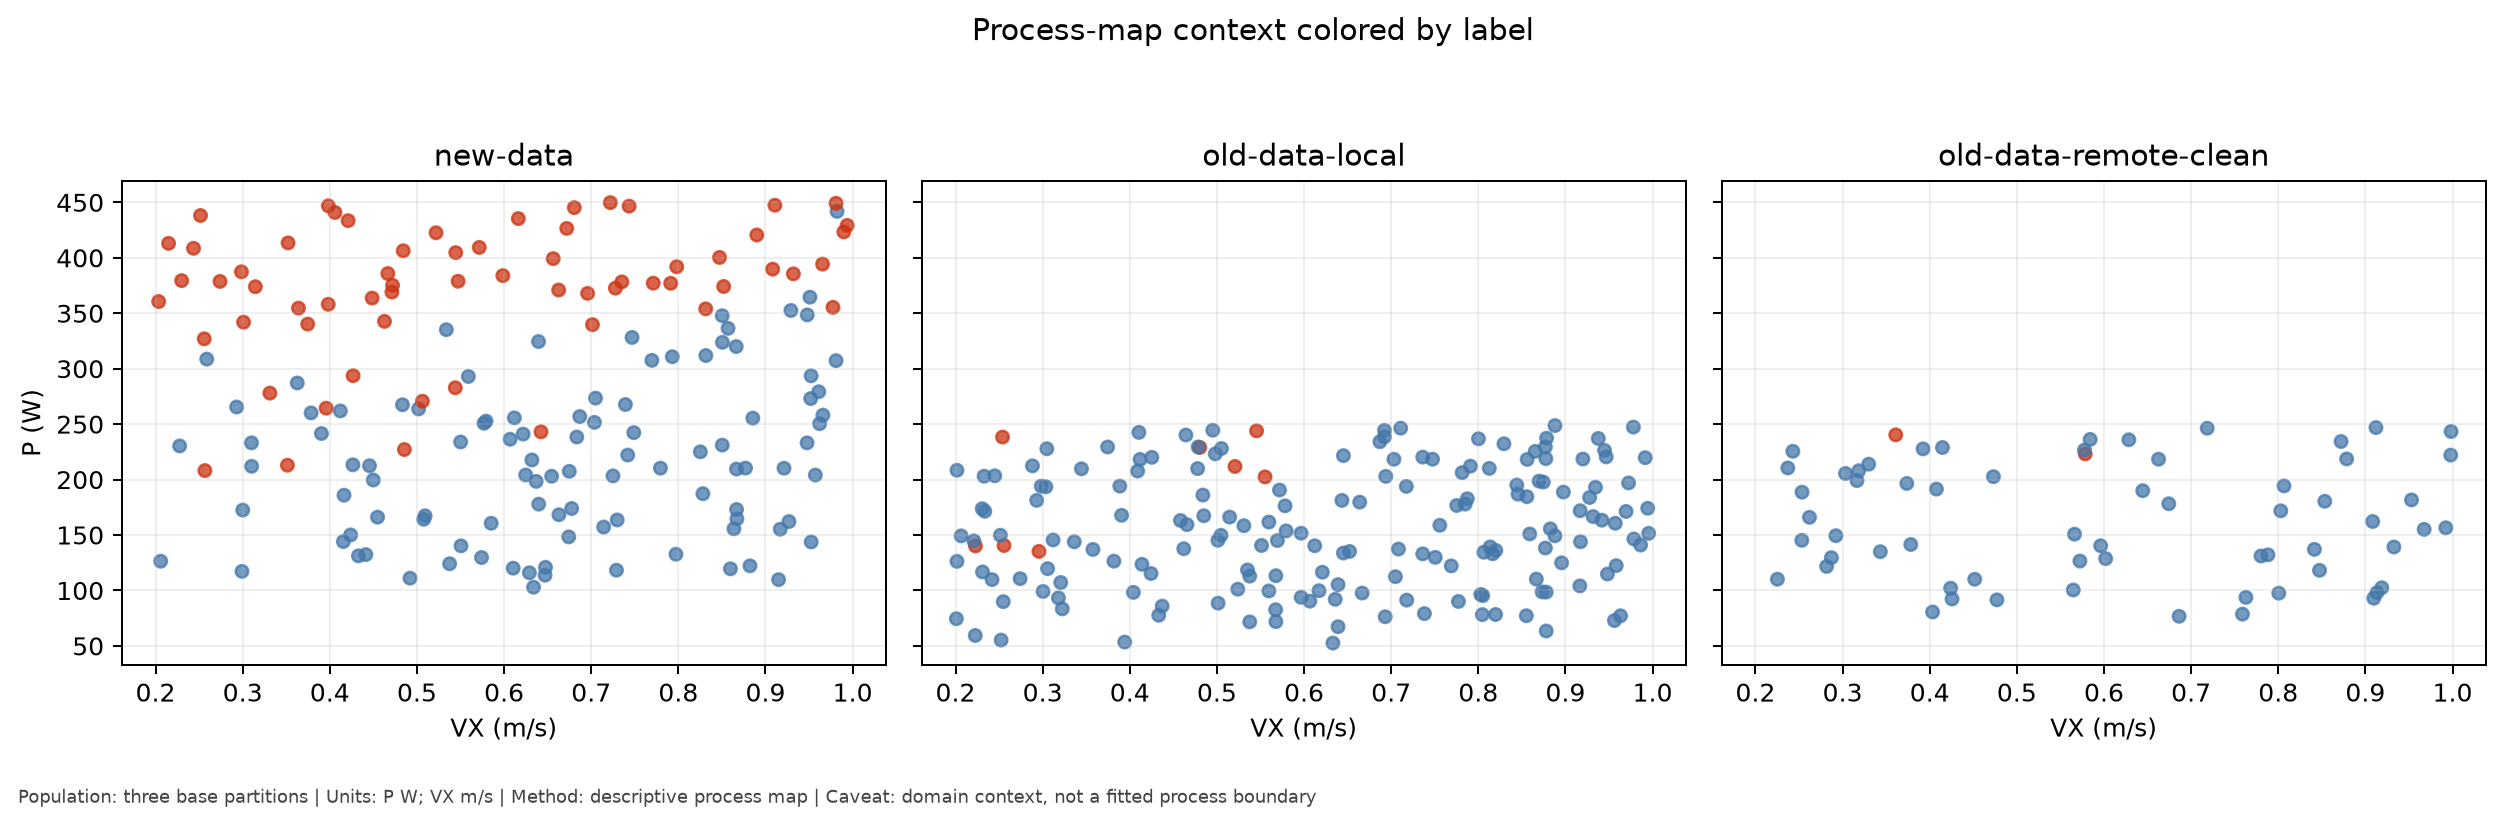

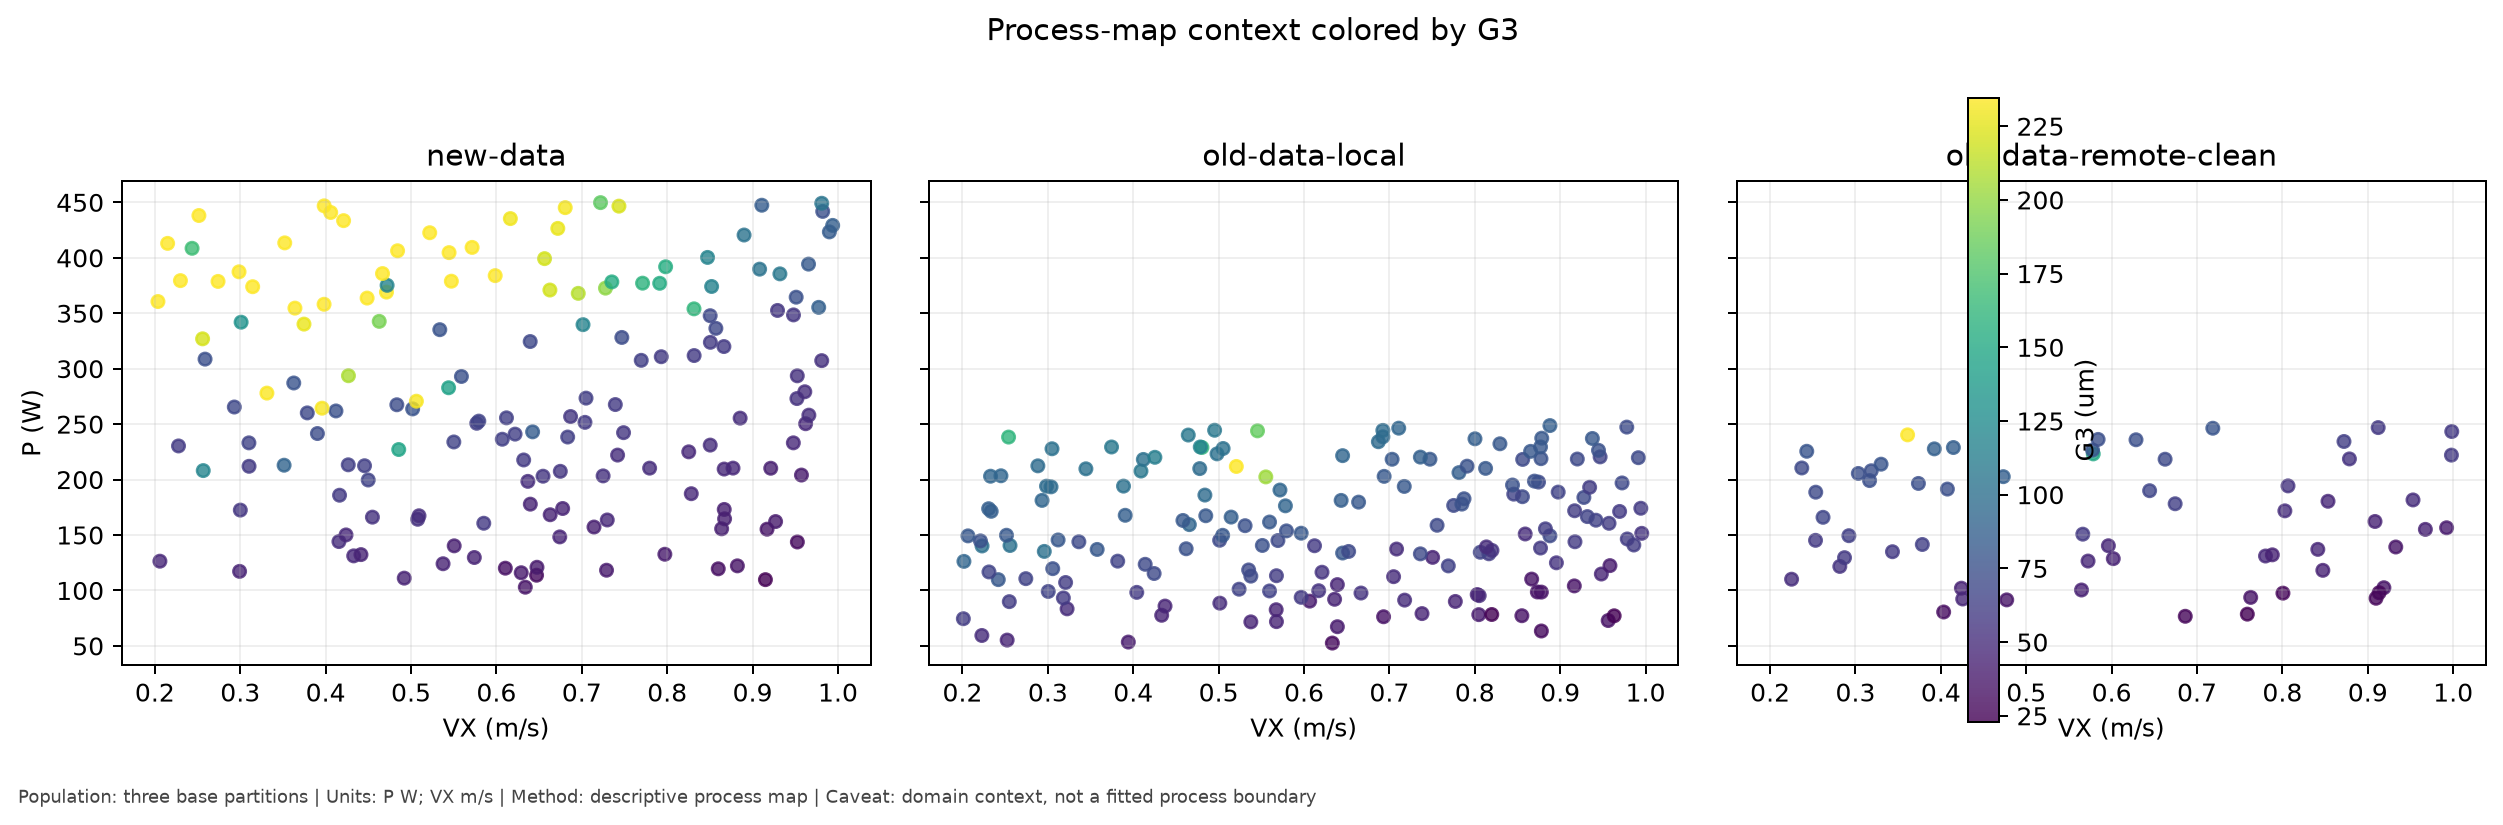

In [15]:
process_map = pd.read_csv(OUT / 'process_map_partition_summary.csv')
display(process_map)
display(Image(filename=str(OUT / 'figures' / '16_process_map_label.png')))
display(Image(filename=str(OUT / 'figures' / '17_process_map_G3.png')))

**Result and interpretation.** The partitions occupy different process ranges and carry sharply different positive prevalence. This supports a domain-shift caveat rather than a universal threshold claim.

## 16. Hard-case linkage

**What are we checking?** Link Phase 4 depth-model hard cases and Phase 5 scalar discordances to current LOO predictions.

**Why does it matter?** Known difficult simulations should remain visible when judging a proxy.

**Interpretation to avoid.** This review does not relabel or exclude any case.

,experiment_name,has_keyhole,consensus_hard_case,phase5_discordant_review_case,loo_correct__G3,loo_signed_margin__G3,keyhole_persistence_group,keyhole_timing_group
0,P-126p384227376_VX-0p205870034079_LS-4p5551405...,False,True,False,True,-42.840378,Keyhole-negative,no_Keyhole
1,P-208p096600196_VX-0p256636148953_LS-4p5249238...,True,True,False,True,51.388487,transient Keyhole,before_T0
2,P-212p944274192_VX-0p351323873231_LS-4p8043939...,True,True,False,True,13.568537,transient Keyhole,before_T0
3,P-227p095146149_VX-0p485569900572_LS-4p6184574...,True,True,False,True,86.661737,persistent Keyhole,spans_multiple_T0_regions
4,P-233p106311211_VX-0p310101846937_LS-6p6327379...,False,True,False,True,-18.368253,Keyhole-negative,no_Keyhole
5,P-260p125654688_VX-0p378472963537_LS-6p2127531...,False,True,False,True,-14.211933,Keyhole-negative,no_Keyhole
6,P-264p370573209_VX-0p395776293281_LS-4p7823602...,True,True,False,True,197.994338,persistent Keyhole,spans_multiple_T0_regions
7,P-277p972333632_VX-0p331196372511_LS-4p5620211...,True,True,False,True,199.087738,persistent Keyhole,spans_multiple_T0_regions
8,P-293p648784497_VX-0p426690912013_LS-5p3394045...,True,True,False,True,165.504537,persistent Keyhole,spans_multiple_T0_regions
9,P-326p931045044_VX-0p255856443683_LS-6p4873723...,True,True,False,True,182.397538,transient Keyhole,before_T0


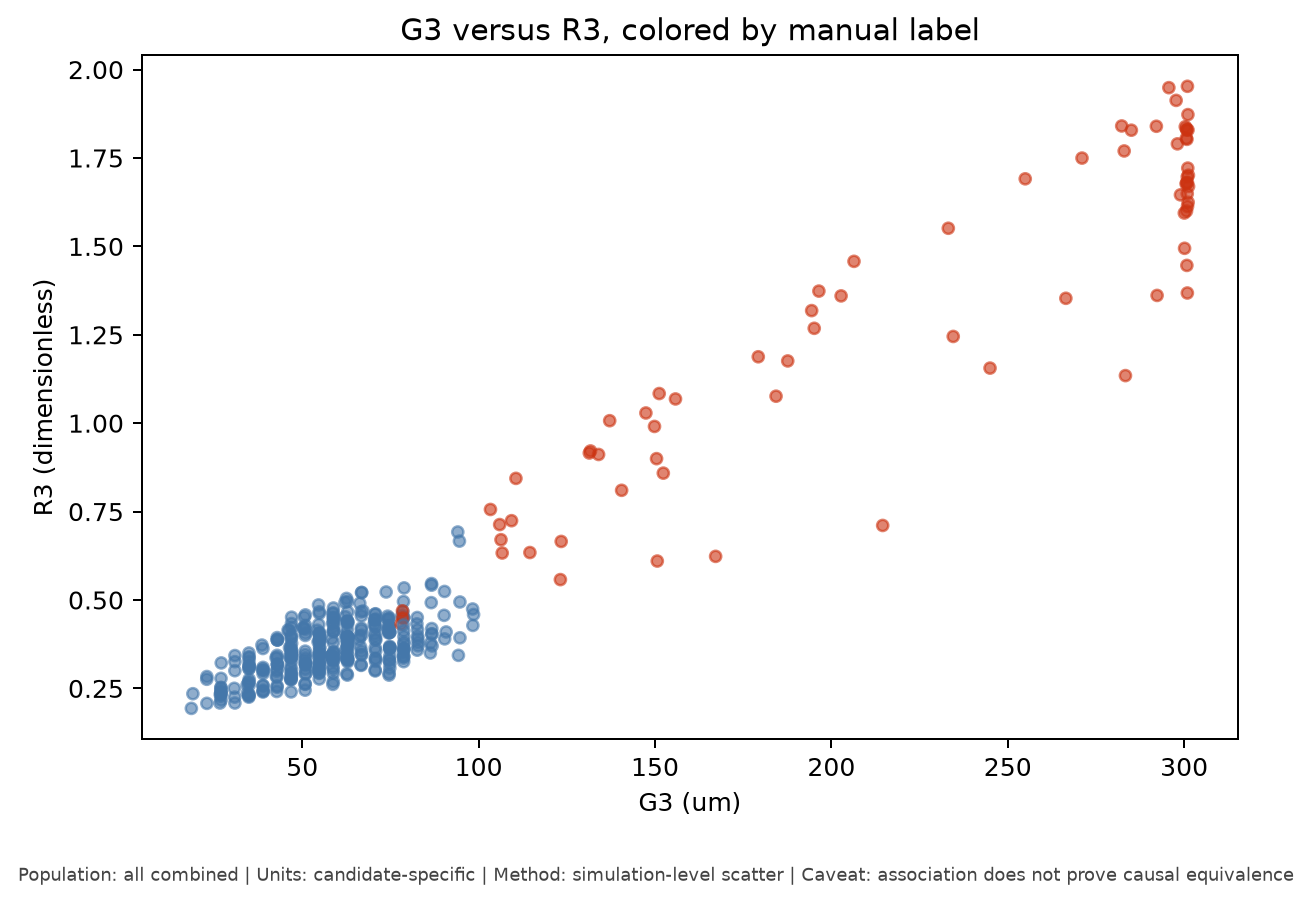

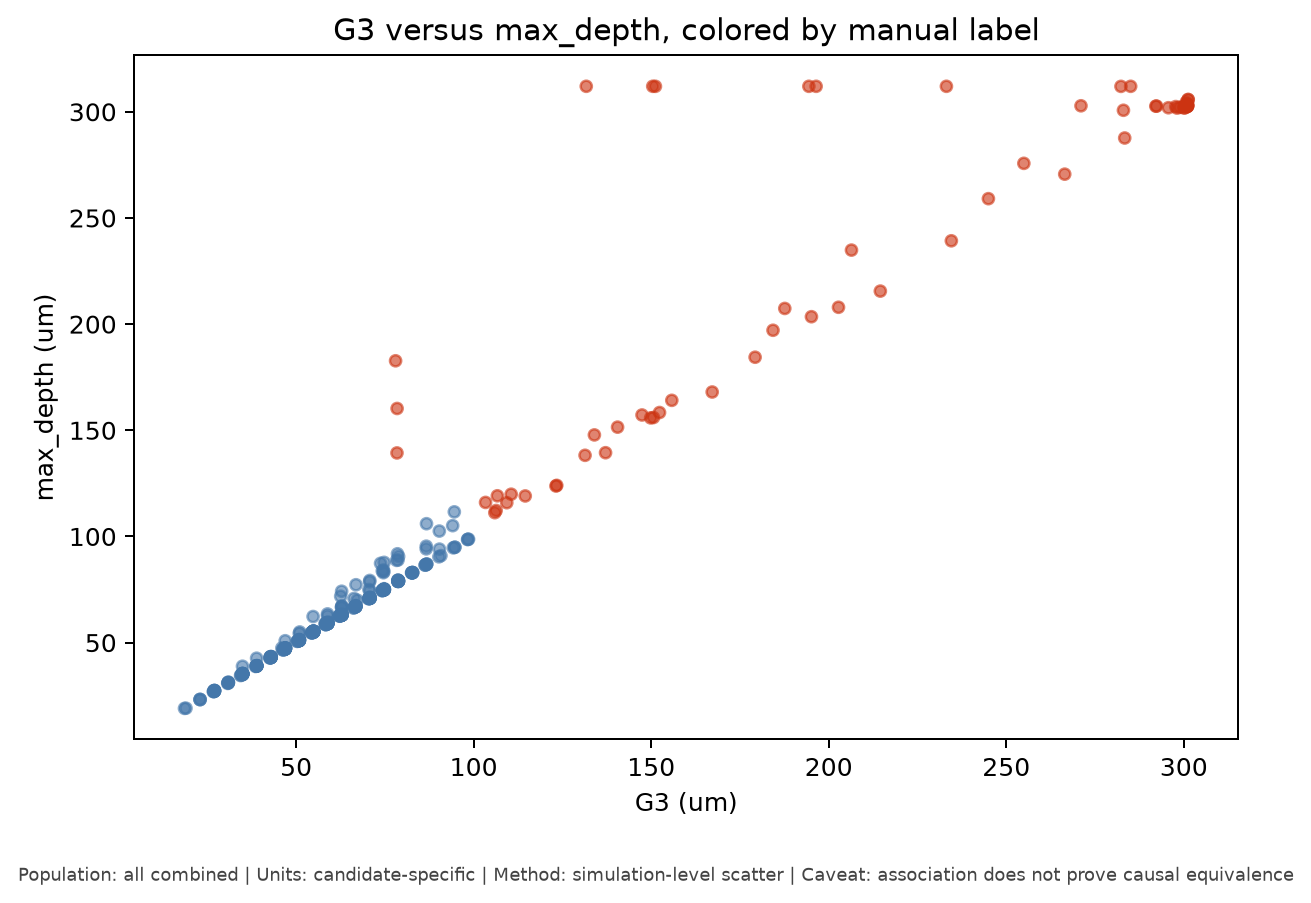

In [16]:
hard = pd.read_csv(OUT / 'phase4_phase5_hard_case_transfer_context.csv')
display(hard[hard['consensus_hard_case'] | hard['phase5_discordant_review_case']][
    ['experiment_name','has_keyhole','consensus_hard_case','phase5_discordant_review_case',
     'loo_correct__G3','loo_signed_margin__G3','keyhole_persistence_group','keyhole_timing_group']
])
display(Image(filename=str(OUT / 'figures' / '18_G3_vs_R3.png')))
display(Image(filename=str(OUT / 'figures' / '19_G3_vs_max_depth.png')))

**Result and interpretation.** Hard cases remain explicit and linked to held-out margins. Their presence supports carrying multiple physical diagnostics forward instead of silently pruning difficult rows.

## 17. Boundary-formulation interpretation

**What are we checking?** Translate the stress tests into a conservative formulation recommendation.

**Why does it matter?** The key decision is whether G3 should be a universal threshold, a continuous companion, or neither.

**Interpretation to avoid.** Do not let a post-hoc scalar threshold overwrite the manual morphology reference.

,0
recommended_boundary_formulation,retain binary has_keyhole reference; do not un...
universal_fixed_G3_threshold_recommended,False
phase6_candidate,compare unchanged binary Keyhole boundary with...
reason,G3 worst held-out transfer balanced accuracy=0...
labels_modified,False
new_target_declared,False
hard_stop,"No predictive modelling, active learning, acqu..."


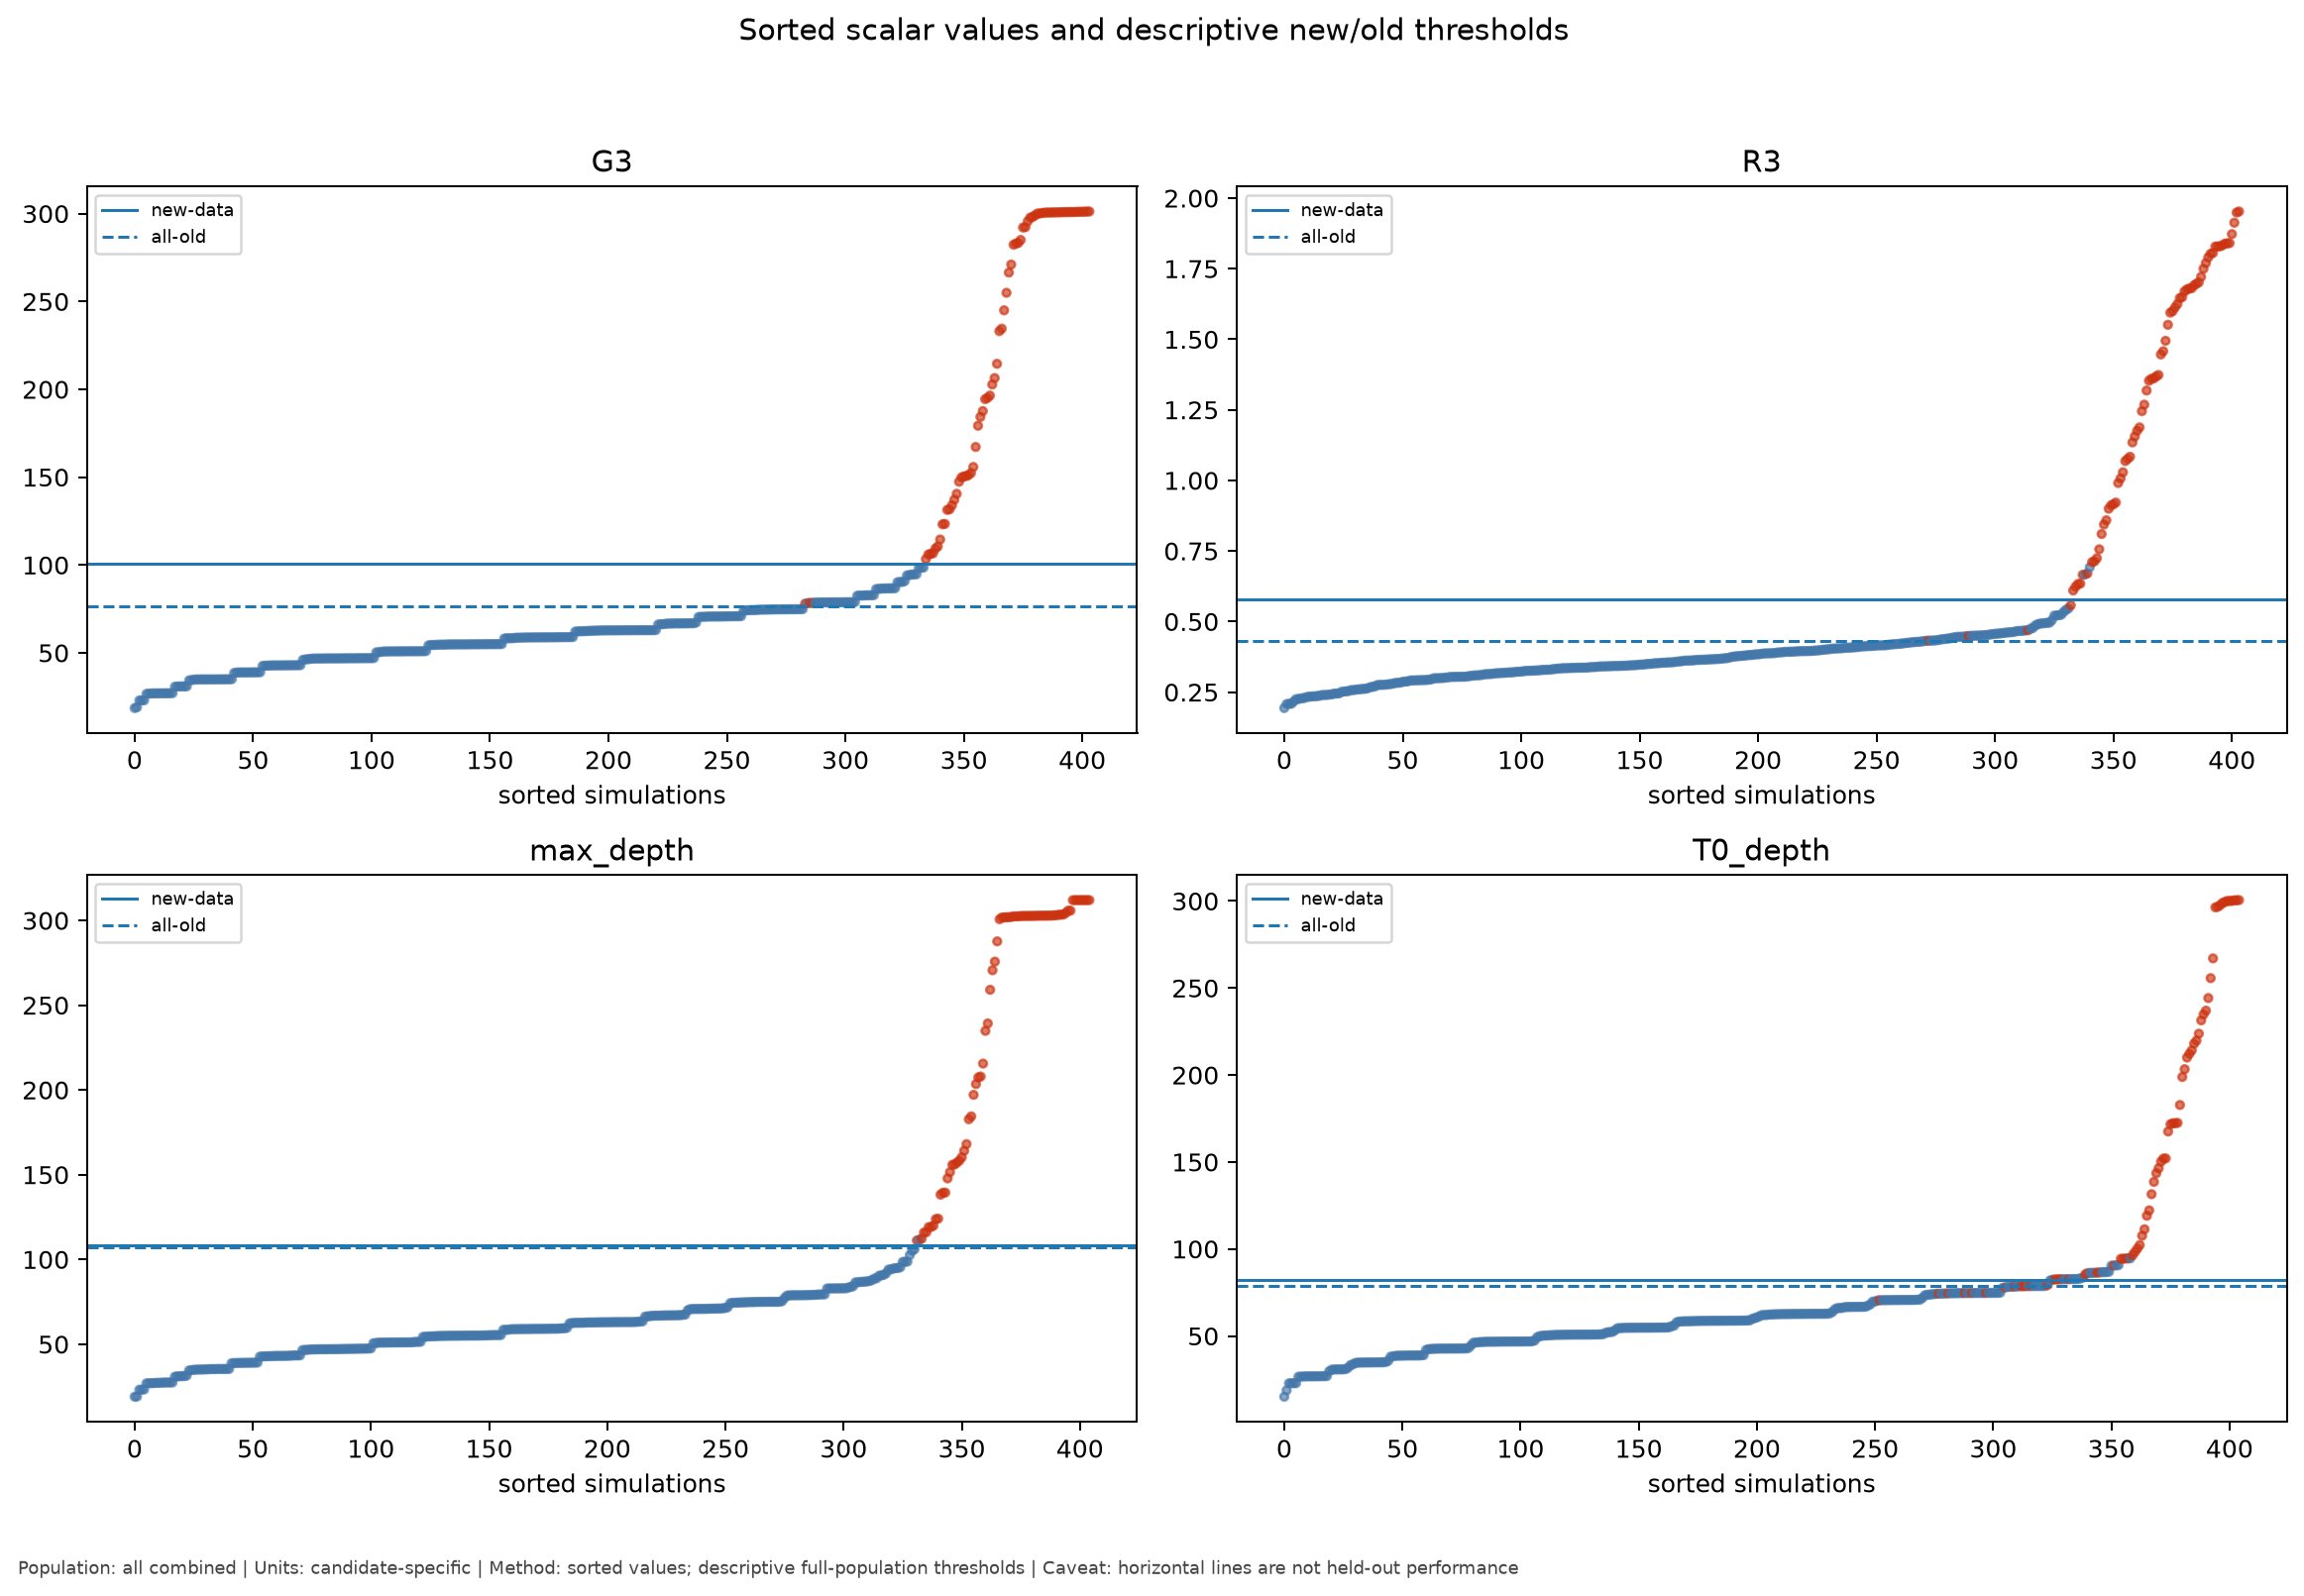

In [17]:
recommendation = pd.read_csv(OUT / 'phase55_boundary_formulation_recommendation.csv')
display(recommendation.T)
display(Image(filename=str(OUT / 'figures' / '07_sorted_values_thresholds.png')))

**Result and interpretation.** The evidence supports retaining binary `has_keyhole`, rejecting a universal fixed G3 threshold, and carrying G3 only as a continuous companion with max depth as the stronger transfer benchmark under a separately approved Phase 6 protocol.

## 18. Final Phase 5.5 recommendation

**What are we checking?** Compare the four primary candidates using the same within/transfer evidence.

**Why does it matter?** A final recommendation should reflect worst-route behavior, not only new-data AUC.

**Interpretation to avoid.** Do not declare the leading scalar to be a causal or label-defining variable.

,candidate_id,robust_across_predeclared_transfer_routes,transferable_with_partition_shift_caveat,decision,mean_within_loo_balanced_accuracy,worst_transfer_balanced_accuracy,worst_transfer_sensitivity,worst_transfer_specificity,direction_agreement_fraction,label_replacement_authorized,interpretation
0,max_depth,True,False,ROBUST CROSS-PARTITION SCALAR COMPANION,0.945752,0.944444,0.888889,0.990099,1.0,False,Physical association and threshold stress test...
1,G3,False,True,TRANSFERABLE WITH PARTITION-SHIFT CAVEAT,0.930529,0.812500,0.625000,0.712871,1.0,False,Physical association and threshold stress test...
2,R3,False,True,TRANSFERABLE WITH PARTITION-SHIFT CAVEAT,0.938955,0.750000,0.500000,0.722772,1.0,False,Physical association and threshold stress test...
3,T0_depth,False,False,PARTITION-SENSITIVE SCALAR COMPANION,0.833029,0.735294,0.500000,0.584158,1.0,False,Physical association and threshold stress test...


,candidate_id,mean_direction_adjusted_roc_auc,minimum_direction_adjusted_roc_auc,mean_within_population_loo_balanced_accuracy,minimum_within_population_loo_balanced_accuracy,mean_cross_population_transfer_balanced_accuracy,minimum_cross_population_transfer_balanced_accuracy,mean_transfer_sensitivity,mean_transfer_specificity,descriptive_direction_agreement_fraction,median_normalized_loo_threshold_iqr,minimum_candidate_availability_fraction,subgroup_rows_evaluated,rank__mean_direction_adjusted_roc_auc,rank__mean_within_population_loo_balanced_accuracy,rank__mean_cross_population_transfer_balanced_accuracy,rank__descriptive_direction_agreement_fraction,rank__minimum_candidate_availability_fraction,aggregate_rank_sum
0,max_depth,0.999960,0.999843,0.945752,0.750000,0.989091,0.944444,0.981481,0.996700,1.0,0.0,0.993939,7,1.0,1.0,1.0,1.0,1.0,5.0
1,G3,0.988543,0.973373,0.930529,0.750000,0.886636,0.812500,0.868981,0.904290,1.0,0.0,0.988827,7,2.0,3.0,2.0,1.0,7.0,15.0
2,T0_depth,0.969412,0.957724,0.833029,0.733607,0.836722,0.735294,0.807672,0.865771,1.0,0.0,0.993939,7,4.0,5.0,4.0,1.0,1.0,15.0
3,R3,0.985907,0.963018,0.938955,0.854660,0.866891,0.750000,0.826190,0.907591,1.0,0.0,0.988827,7,3.0,2.0,3.0,1.0,7.0,16.0


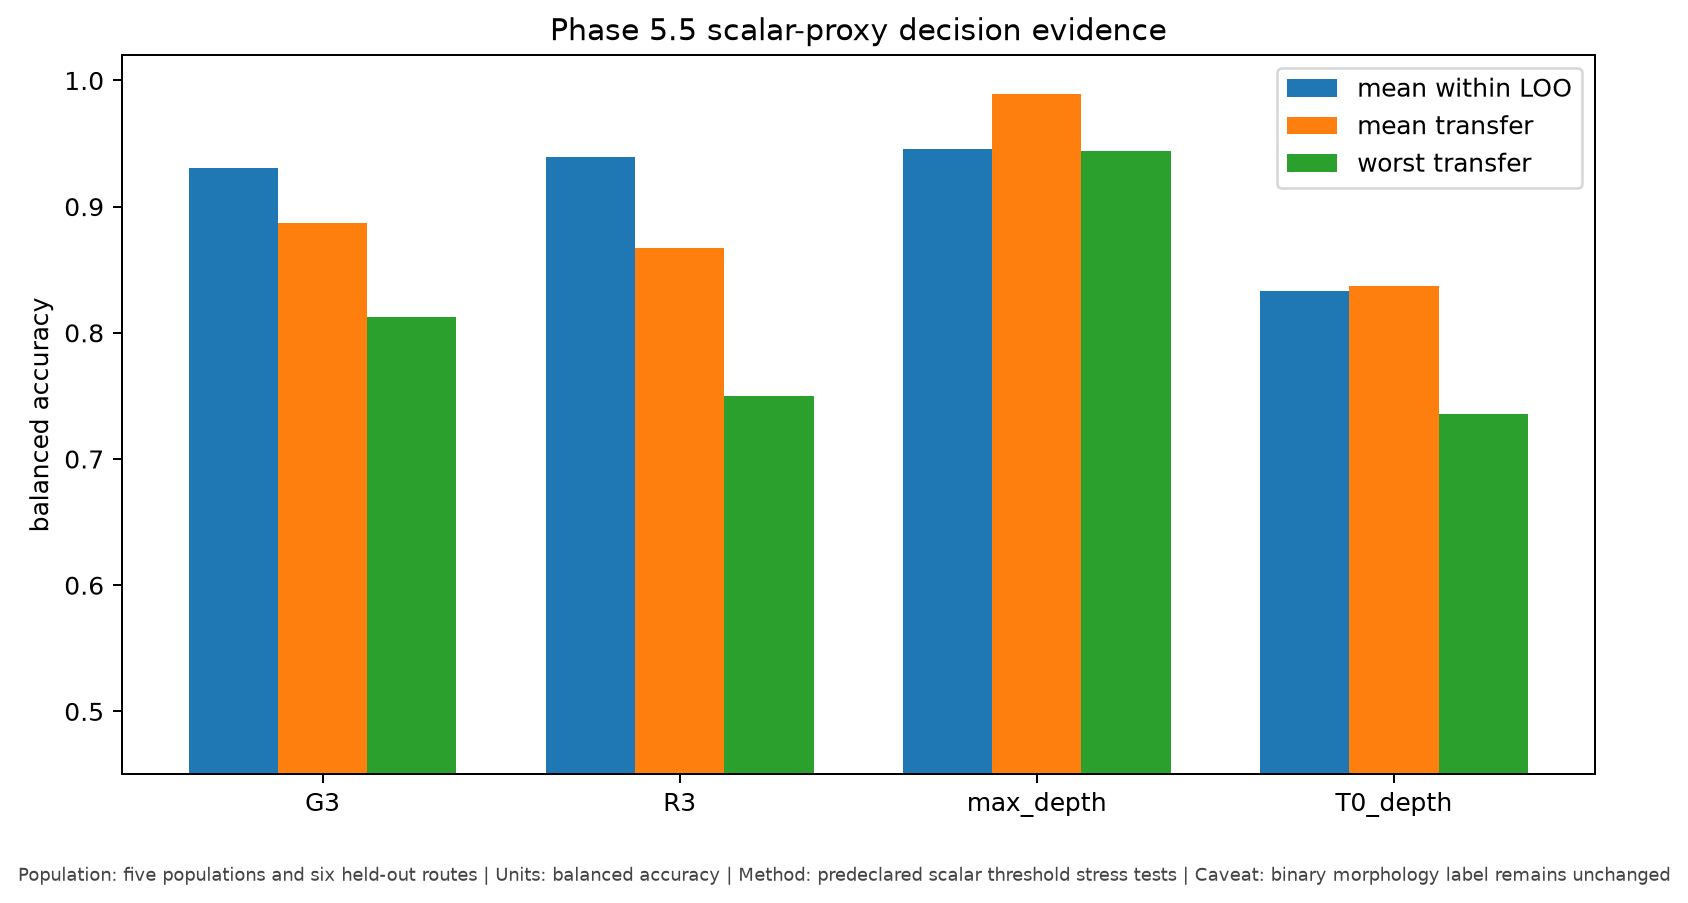

In [18]:
decisions = pd.read_csv(OUT / 'g3_vs_r3_vs_max_vs_t0_transfer_decision.csv')
scorecard = pd.read_csv(OUT / 'phase55_scorecard.csv')
display(decisions)
display(scorecard[scorecard['candidate_id'].isin(['G3','R3','max_depth','T0_depth'])])
display(Image(filename=str(OUT / 'figures' / '20_phase55_decision_summary.png')))

**Result and interpretation.** Max depth is the robust cross-partition benchmark (worst transfer BA 0.944). G3 is transferable with a partition-shift caveat (worst BA 0.812, worst sensitivity 0.625).

## 19. Validation

**What are we checking?** Show automated scientific, scope, and artifact checks.

**Why does it matter?** A teaching narrative is trustworthy only if its stored outputs match validated artifacts.

**Interpretation to avoid.** Passing checks do not eliminate sampling limitations.

In [19]:
validation = pd.read_csv(OUT / 'validation_results.csv')
requirements = pd.read_csv(OUT / 'requirement_checklist.csv')
display(validation)
display(requirements)

,check_id,check,status,detail,category
0,V01,Phase 5.5 branch and exact Phase 5 parent,PASS,codex/week7-phase5-5-g3-robustness-transfer @ ...,provenance
1,V02,Committed Phase 5 local/upstream/remote equality,PASS,local=3367f4c9b5af2def802f72a65258f5cc01896bac...,provenance
2,V03,Live HF main is the analysed revision,PASS,b6dc254a2b607a31cb9f97b40990339c3d5ca1e8,dataset
3,V04,HF diff is exactly 110 approved additions,PASS,"{'kinetic-energy_melt.dat': 55, 'time.dat': 55}",dataset
4,V05,"Labels, new-data, geometry, and iteration path...",PASS,all protected path classes unchanged,dataset
5,V06,Exactly 55 pinned failures changed to current ...,PASS,status_changed=55,target_refresh
6,V07,No unchanged-input target status changed,PASS,unexpected=0,target_refresh
7,V08,All 407 simulations retained with 405 usable,PASS,rows=407; usable=405,target_refresh
8,V09,Partition readiness counts are exact,PASS,164/165; 178/179; 63/63; 241/242; 405/407,target_refresh
9,V10,Candidate availability is explicit for all fiv...,PASS,rows=40,population


,requirement_id,requirement,status,validation_checks
0,R01,Exact Phase 5 parent and safe Phase 5 publication,PASS,V01;V02
1,R02,Exact merged HF snapshot and bounded restorati...,PASS,V03;V04;V05
2,R03,Current target refresh and full-row retention,PASS,V06;V07;V08;V09
3,R04,Five population composition and candidate avai...,PASS,V10
4,R05,Leakage-free within-population LOO thresholds,PASS,V11;V12
5,R06,Disjoint cross-population transfer,PASS,V13;V14
6,R07,"5,000-resample simulation-level uncertainty",PASS,V15;V16
7,R08,Threshold gaps and conservative G3 decision,PASS,V17;V18
8,R09,Twenty explanatory figures,PASS,V19
9,R10,Twenty-section executed teaching notebook,PASS,V20


**Result and interpretation.** The full analysis produced 24 passing core checks and 12 passing requirements before notebook-aware closeout validation.

## 20. Hard stop

**What are we checking?** Restate what Phase 5.5 did not do.

**Why does it matter?** Clear stopping boundaries prevent scalar diagnostics from silently becoming predictive modelling.

**Interpretation to avoid.** Do not continue into classifiers, Gaussian processes, active learning, acquisition, or level-set estimation here.

In [20]:
scope = summary['scope']
pd.Series({
    'predictive_models_fitted': scope['predictive_models_fitted'],
    'classifiers_fitted': scope['classifiers_fitted'],
    'active_learning_run': scope['active_learning_run'],
    'level_set_estimated': scope['level_set_estimated'],
    'labels_modified': scope['labels_modified'],
    'simulations_removed': scope['simulations_removed'],
    'phase55_committed_or_pushed': False,
})

predictive_models_fitted       False
classifiers_fitted             False
active_learning_run            False
level_set_estimated            False
labels_modified                False
simulations_removed            False
phase55_committed_or_pushed    False
dtype: bool

**Result and interpretation.** Phase 5.5 stops at validated robustness and transfer diagnostics. The work remains uncommitted and unpushed, as requested.